In [31]:
!pip install pandas
!pip install matplotlib
!pip install seaborn 
!pip install statsmodels
!pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# ローカルレベルモデル

In [32]:
!pip install --upgrade plotly


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import plotly.express as px
import numpy as np

In [34]:
df = pd.read_csv('../data/Transport_amount_data.csv')
df['label'] = pd.to_datetime(df['label'])
df

,label,year,month,Transport_tonnage,number_parcels,Number_companies_1,Number_companies_2
0,2002-04-01,2002,4,5933686,218721,26,20
1,2002-05-01,2002,5,5474539,208283,26,20
2,2002-06-01,2002,6,5430018,218633,26,20
3,2002-07-01,2002,7,6345951,271764,26,20
4,2002-08-01,2002,8,5354671,217650,26,20
...,...,...,...,...,...,...,...
239,2022-03-01,2022,3,6118588,426615,24,14
240,2022-04-01,2022,4,5727532,387559,24,14
241,2022-05-01,2022,5,5102766,380692,24,14
242,2022-06-01,2022,6,5723215,411429,24,14


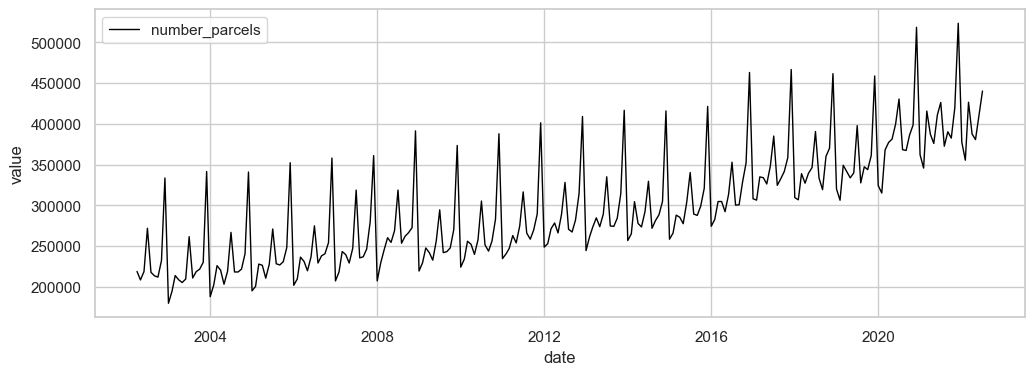

In [35]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 4))

# 原系列
sns.lineplot(data=df, x=df['label'], y=df['number_parcels'], label='number_parcels', color='black', lw=1.0)
#plt.title('')
plt.xlabel('date')
plt.ylabel('value')
plt.legend()

In [36]:
df['sma12'] = df['number_parcels'].rolling(12).mean()
df

,label,year,month,Transport_tonnage,number_parcels,Number_companies_1,Number_companies_2,sma12
0,2002-04-01,2002,4,5933686,218721,26,20,NaN
1,2002-05-01,2002,5,5474539,208283,26,20,NaN
2,2002-06-01,2002,6,5430018,218633,26,20,NaN
3,2002-07-01,2002,7,6345951,271764,26,20,NaN
4,2002-08-01,2002,8,5354671,217650,26,20,NaN
...,...,...,...,...,...,...,...,...
239,2022-03-01,2022,3,6118588,426615,24,14,404079.333333
240,2022-04-01,2022,4,5727532,387559,24,14,404095.333333
241,2022-05-01,2022,5,5102766,380692,24,14,404489.250000
242,2022-06-01,2022,6,5723215,411429,24,14,404545.166667


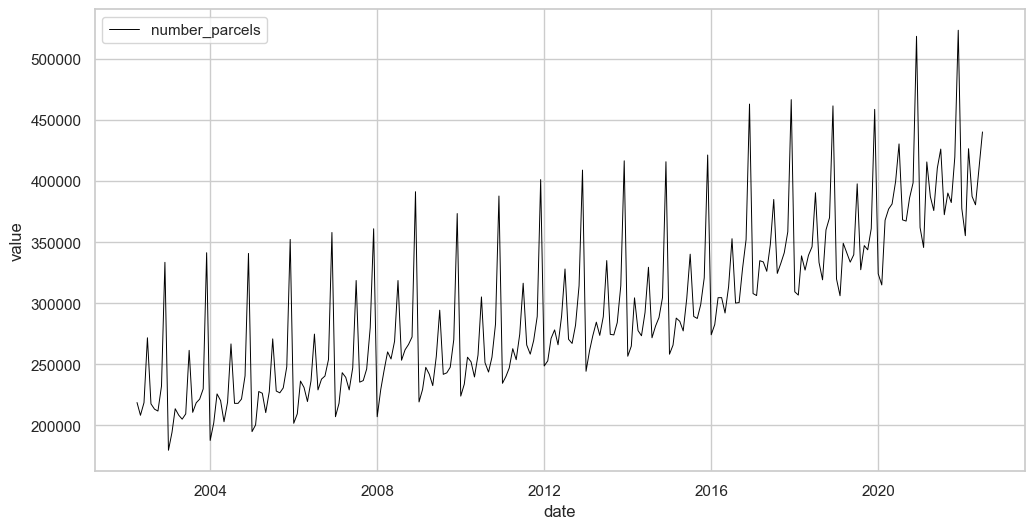

In [37]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

# 原系列
sns.lineplot(data=df, x=df['label'], y=df['number_parcels'], label='number_parcels', color='black', lw=0.7)
# 単純移動平均
#sns.lineplot(data=df, x=df['label'], y=df['sma12'], label='sma12', color='blue', lw=0.7)
#plt.title('')
plt.xlabel('date')
plt.ylabel('value')
plt.legend()

In [38]:
df['y'] = np.log(df['number_parcels'])
df

,label,year,month,Transport_tonnage,number_parcels,Number_companies_1,Number_companies_2,sma12,y
0,2002-04-01,2002,4,5933686,218721,26,20,NaN,12.295552
1,2002-05-01,2002,5,5474539,208283,26,20,NaN,12.246653
2,2002-06-01,2002,6,5430018,218633,26,20,NaN,12.295150
3,2002-07-01,2002,7,6345951,271764,26,20,NaN,12.512689
4,2002-08-01,2002,8,5354671,217650,26,20,NaN,12.290644
...,...,...,...,...,...,...,...,...,...
239,2022-03-01,2022,3,6118588,426615,24,14,404079.333333,12.963637
240,2022-04-01,2022,4,5727532,387559,24,14,404095.333333,12.867623
241,2022-05-01,2022,5,5102766,380692,24,14,404489.250000,12.849746
242,2022-06-01,2022,6,5723215,411429,24,14,404545.166667,12.927392


In [39]:
import numpy as np
import statsmodels.api as sm

class LocalLevelSeasonalModel(sm.tsa.statespace.MLEModel):
    """
    状態空間モデル: トレンド＋季節成分（周期12）
    """
    param_names = ['obs_error', 'trend_error', 'seasonal_error']
    positive_params = [0, 1, 2]
    start_params = [0, 0, 0.5]
    k_posdef = 2  # 状態誤差の次元数（トレンド成分と季節成分）

    def __init__(self, endog):
        """
        コンストラクタ
        :param endog: 観測データ（時系列）
        """
        # トレンド成分1 + 季節成分11個 = 状態数12
        super().__init__(endog=endog, k_states=12, k_posdef=self.k_posdef, initialization='diffuse')

        # デザイン行列 (トレンド + 季節成分の最初の1個)
        self.ssm['design'] = np.zeros((1, 12))
        self.ssm['design', 0, 0] = 1  # トレンド
        self.ssm['design', 0, 1] = 1  # 季節成分（最初の1個）

        # 観測切片なし
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

        # 状態遷移行列
        self.ssm['transition'] = np.zeros((12, 12))
        self.ssm['transition', 0, 0] = 1  # トレンドはランダムウォーク
        self.ssm['transition', 1, 1:] = -1  # ここを変更!
        self.ssm['transition', 2, 1] = 1
        self.ssm['transition', 3, 2] = 1
        self.ssm['transition', 4, 3] = 1
        self.ssm['transition', 5, 4] = 1
        self.ssm['transition', 6, 5] = 1
        self.ssm['transition', 7, 6] = 1
        self.ssm['transition', 8, 7] = 1
        self.ssm['transition', 9, 8] = 1
        self.ssm['transition', 10, 9] = 1
        self.ssm['transition', 11, 10] = 1

        # 選択行列 (状態ノイズ)
        self.ssm['selection'] = np.zeros((12, 2))
        self.ssm['selection', 0, 0] = 1  # トレンド成分にトレンド誤差
        self.ssm['selection', 1, 1] = 1  # 季節成分に季節誤差

    def transform_params(self, unconstrained):
        """非制約パラメータを制約付きパラメータに変換 (正の値)"""
        constrained = unconstrained.copy()
        constrained[self.positive_params] = unconstrained[self.positive_params] ** 2
        return constrained

    def untransform_params(self, constrained):
        """制約付きパラメータを非制約パラメータに変換"""
        unconstrained = constrained.copy()
        unconstrained[self.positive_params] = constrained[self.positive_params] ** 0.5
        return unconstrained

    def update(self, params, **kwargs):
        """パラメータを更新"""
        params = super().update(params, **kwargs)
        self['obs_cov', 0, 0] = params[0]  # 観測誤差
        self['state_cov', 0, 0] = params[1]  # トレンド誤差
        self['state_cov', 1, 1] = params[2]  # 季節誤差

In [40]:
# モデルのデータ準備
endog = df['y']

# モデルのインスタンス化
model = LocalLevelSeasonalModel(
    endog=endog,
)

# モデルのフィッティング
result_base = model.fit(disp=False)
print(result_base.summary())

                              Statespace Model Results                             
Dep. Variable:                           y   No. Observations:                  244
Model:             LocalLevelSeasonalModel   Log Likelihood                 471.943
Date:                     Sun, 25 Jan 2026   AIC                           -913.885
Time:                             15:12:30   BIC                           -861.428
Sample:                                  0   HQIC                          -892.758
                                     - 244                                         
Covariance Type:                       opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
obs_error          0.0002   4.86e-05      4.297      0.000       0.000       0.000
trend_error        0.0002   2.85e-05      5.917      0.000       0.000       0.

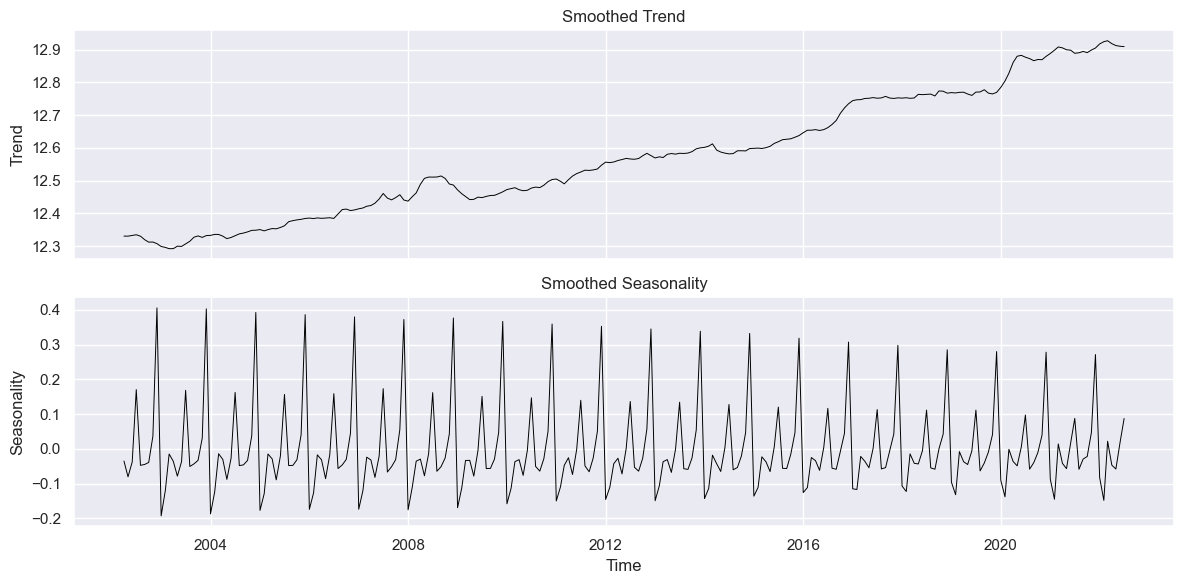

In [41]:
estimated_states = result_base.smoothed_state
trend = estimated_states[0]
seasonal = estimated_states[1]

result_df = pd.DataFrame({
    '日付': df['label'],
    '観測値': df['y'],
    'トレンド': trend,
    'トレンド+季節性': trend+seasonal,
    '季節性': seasonal})

# seabornスタイル
sns.set(style="darkgrid")

# 図の作成
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# トレンドのプロット
sns.lineplot(ax=axes[0], x=result_df['日付'], y=trend, color="black", lw=0.7)
#sns.lineplot(ax=axes[0], x=result_df['日付'], y=result_df['観測値'], color="black", lw=0.7)
axes[0].set_title('Smoothed Trend')
axes[0].set_ylabel('Trend')

# 季節成分のプロット
sns.lineplot(ax=axes[1], x=result_df['日付'], y=seasonal, color="black", lw=0.7)
axes[1].set_title('Smoothed Seasonality')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Seasonality')

plt.tight_layout()
plt.show()

In [42]:
estimated_states = result_base.smoothed_state
trend = estimated_states[0]
seasonal = estimated_states[1]

result_df = pd.DataFrame({
    '日付': df['label'],
    '観測値': df['y'],
    'トレンド': trend,
    'トレンド+季節性': trend+seasonal,
    '季節性': seasonal
})
result_df_melted = result_df.melt(
    id_vars='日付',
    var_name='decomposition',
    value_name='対数系列'
).sort_values(by='日付')

fig = px.line(
    data_frame = result_df_melted,
    x = '日付',
    y = '対数系列',
    color = 'decomposition'
)
fig.show()

In [43]:
df['y']

0      12.295552
1      12.246653
2      12.295150
3      12.512689
4      12.290644
         ...    
239    12.963637
240    12.867623
241    12.849746
242    12.927392
243    12.995309
Name: y, Length: 244, dtype: float64

In [44]:
trend+seasonal

array([12.29531661, 12.24971848, 12.2947808 , 12.50488186, 12.28271437,
       12.27448076, 12.27283803, 12.34871003, 12.71295752, 12.10586827,
       12.17619223, 12.27713167, 12.25603876, 12.22101165, 12.26227083,
       12.47475628, 12.26368735, 12.28389346, 12.29788074, 12.35782996,
       12.73479768, 12.14537967, 12.2118456 , 12.32129176, 12.29973993,
       12.23478014, 12.29906825, 12.49398622, 12.28884927, 12.29369404,
       12.30997388, 12.38575527, 12.74081368, 12.17311179, 12.21724921,
       12.3353194 , 12.32454968, 12.26341178, 12.33669953, 12.51849381,
       12.32620462, 12.33002858, 12.34823281, 12.4223534 , 12.77048851,
       12.21126889, 12.25692293, 12.36871213, 12.35296575, 12.29958601,
       12.36972406, 12.54321322, 12.34134219, 12.36496529, 12.38268232,
       12.45316591, 12.79005842, 12.23990413, 12.2960542 , 12.39762432,
       12.39181699, 12.34880834, 12.4227958 , 12.63370388, 12.37970072,
       12.38981975, 12.41659617, 12.51183506, 12.81272704, 12.26

In [45]:
# 残差の計算
H = model.ssm['design'][0]  # H

# 事前推定値 (one-step-ahead predictions) を取得
predicted_states = result_base.predicted_state

# 残差の計算（事前推定値を使用）
predicted_y_prior = H @ predicted_states  # Hx_{n|n-1}

# predicted_y_prior の最後の要素を削除して形状を合わせる
predicted_y_prior = predicted_y_prior[:-1]

residuals = endog - predicted_y_prior

residuals_df = pd.DataFrame({
    'Time': df.index,
    'Residuals': residuals
})
residuals_df

,Time,Residuals
0,0,12.295552
1,1,12.246653
2,2,6.147374
3,3,4.315789
4,4,3.014796
...,...,...
239,239,0.041585
240,240,-0.027313
241,241,-0.023431
242,242,-0.007643


In [46]:
residuals_df[:20]

,Time,Residuals
0,0,12.295552
1,1,12.246653
2,2,6.147374
3,3,4.315789
4,4,3.014796
5,5,2.391634
6,6,1.985791
7,7,1.794111
8,8,1.932217
9,9,1.098670


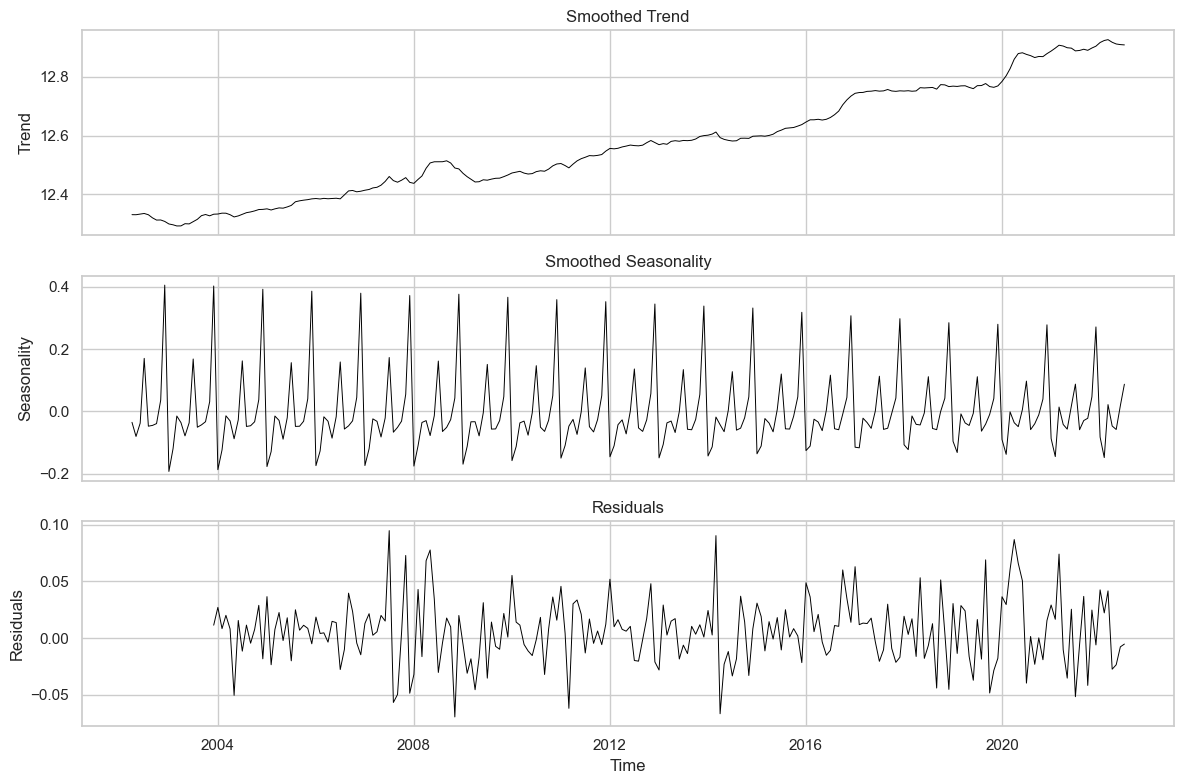

In [47]:
estimated_states = result_base.smoothed_state
trend = estimated_states[0]
seasonal = estimated_states[1]

result_df = pd.DataFrame({
    '日付': df['label'],
    '観測値': df['y'],
    'トレンド': trend,
    'トレンド+季節性': trend+seasonal,
    '季節性': seasonal})

# seabornスタイル
sns.set(style="whitegrid")

# 図の作成
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# トレンドのプロット
sns.lineplot(ax=axes[0], x=result_df['日付'], y=trend, color="black", lw=0.7)
#sns.lineplot(ax=axes[0], x=result_df['日付'], y=result_df['観測値'], color="black", lw=0.7)
axes[0].set_title('Smoothed Trend')
axes[0].set_ylabel('Trend')

# 季節成分のプロット
sns.lineplot(ax=axes[1], x=result_df['日付'], y=seasonal, color="black", lw=0.7)
axes[1].set_title('Smoothed Seasonality')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Seasonality')

# 残差のプロット
sns.lineplot(ax=axes[2], x=result_df['日付'], y=residuals_df['Residuals'][20:], color="black", lw=0.7)
axes[2].set_title('Residuals')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [48]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

ucm = UnobservedComponents(
    endog=df['y'],
    level='local linear trend',
    seasonal=12,
)
res_ucm = ucm.fit(disp=False)

# get_forecast が使える
fc = res_ucm.get_forecast(steps=48)
fc_df = fc.summary_frame()
fc_df

c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



y,mean,mean_se,mean_ci_lower,mean_ci_upper
244,12.856966,0.028949,12.800226,12.913705
245,12.887486,0.030305,12.828090,12.946882
246,12.897526,0.032398,12.834028,12.961024
247,12.968446,0.034405,12.901013,13.035879
248,13.195880,0.036321,13.124692,13.267068
249,12.844704,0.038154,12.769924,12.919484
250,12.782201,0.039909,12.703980,12.860422
251,12.954619,0.041590,12.873105,13.036134
252,12.888539,0.043184,12.803900,12.973178
253,12.879255,0.044655,12.791734,12.966777


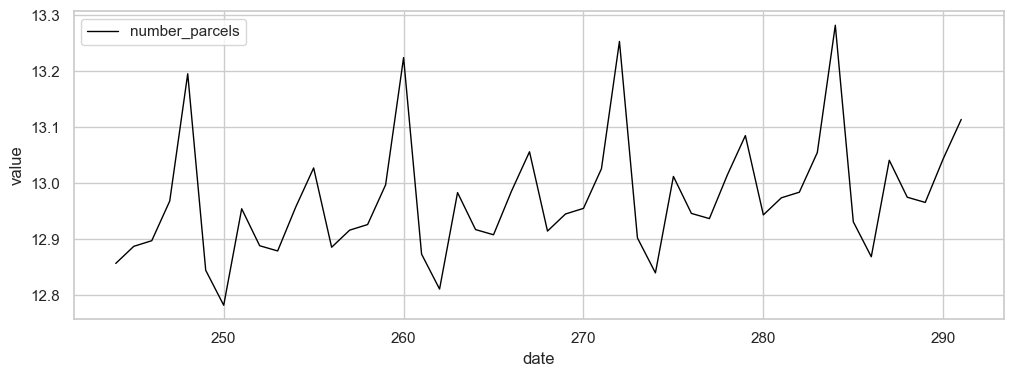

In [49]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 4))

# 原系列
sns.lineplot(x=fc_df.index, y=fc_df['mean'], label='number_parcels', color='black', lw=1.0)
#plt.title('')
plt.xlabel('date')
plt.ylabel('value')
plt.legend()

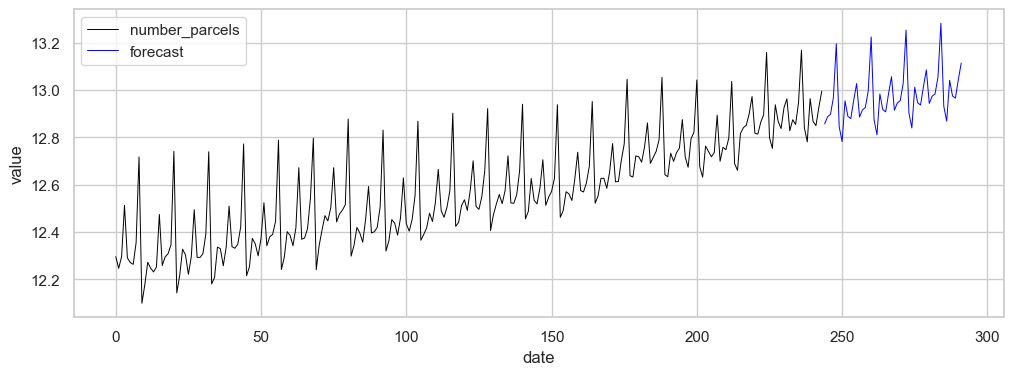

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 前提 ---
# df['y']           : 実測値（時系列）
# fc_df['forecast'] : 予測結果（DataFrame, 先頭行は予測の1ステップ目）

# 1. 観測値の最後のタイムインデックスと値
last_idx   = df.index[-1]
last_value = df['y'].iloc[-1]

# 2. 予測の1ステップ目のタイムインデックスと値
first_fc_idx   = fc_df.index[0]
first_fc_value = fc_df['mean'].iloc[0]

# 3. 結合用 Series を作成
combined = pd.Series(
    [last_value, first_fc_value],
    index=[last_idx, first_fc_idx]
)

# プロット
sns.set_style('whitegrid')
plt.figure(figsize=(12, 4))

# 原系列
sns.lineplot(x=df.index, y=df['y'], label='number_parcels', color='black', lw=0.7)
# 予測
sns.lineplot(x=fc_df.index, y=fc_df['mean'], label='forecast', color='blue', lw=0.7)
#plt.title('')
plt.xlabel('date')
plt.ylabel('value')
plt.legend()

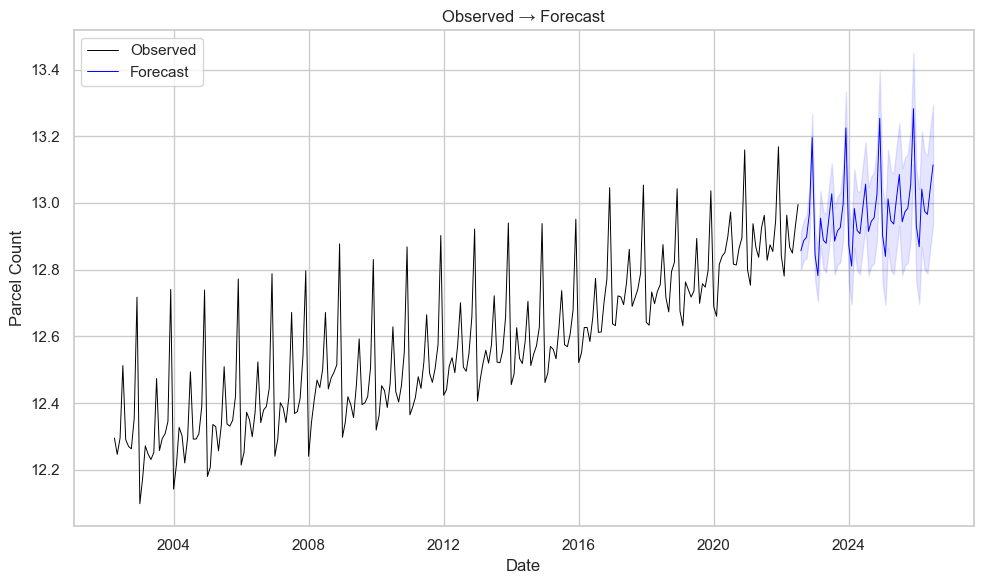

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 準備 ---
# 1) df['label'] を datetime に変換してインデックスに
df_plot = df.copy()
df_plot['label'] = pd.to_datetime(df_plot['label'])
df_plot.set_index('label', inplace=True)

# 2) fc_df のインデックスを未来の月初に設定（2022-08-01 から）
#    df_plot の最終日時 + MonthBegin(1) をスタートに
h = len(fc_df)
start = df_plot.index[-1] + pd.offsets.MonthBegin(1)
future_idx = pd.date_range(start=start, periods=h, freq='MS')
fc_df = fc_df.copy()
fc_df.index = future_idx

# --- プロット ---
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# 実測値
sns.lineplot(
    x=df_plot.index,
    y=df_plot['y'],
    label='Observed',
    color='black',
    lw=0.7
)

# 予測平均
sns.lineplot(
    x=fc_df.index,
    y=fc_df['mean'],
    label='Forecast',
    color='blue',
    lw=0.7
)

# 95% 信頼区間
plt.fill_between(
    fc_df.index,
    fc_df['mean_ci_lower'],
    fc_df['mean_ci_upper'],
    color='blue',
    alpha=0.1
)

plt.xlabel('Date')
plt.ylabel('Parcel Count')
plt.title('Observed → Forecast')
plt.legend()
plt.tight_layout()
plt.show()

## テスト

In [52]:
smoothed_states = result_base.smoothed_state  # shape = (k_states, T)
smoothed_trend = smoothed_states[0]
smoothed_seasonal = smoothed_states[1]

def forecast_mlemodel(res, steps=24):
    transition = res.model.ssm['transition']
    design     = res.model.ssm['design']
    # 最終時点の平滑化状態を初期化
    state = res.smoothed_state[:, -1].copy()
    forecasts = []

    for _ in range(steps):
        # 観測の点予測
        forecasts.append(float(design @ state))
        # 状態を1ステップ進める
        state = transition @ state

    return np.array(forecasts)

# まず transition を修正してから再フィット or update してください
# その上で
fc_vals = forecast_mlemodel(result_base, steps=60)
fc_vals

C:\Users\fugat\AppData\Local\Temp\ipykernel_51932\999091047.py:14: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



array([12.99656648, 12.85069636, 12.87985025, 12.88722647, 12.95616204,
       13.18060647, 12.82681786, 12.76096929, 12.93113486, 12.86237679,
       12.85119267, 12.92776734, 12.99656648, 12.85069636, 12.87985025,
       12.88722647, 12.95616204, 13.18060647, 12.82681786, 12.76096929,
       12.93113486, 12.86237679, 12.85119267, 12.92776734, 12.99656648,
       12.85069636, 12.87985025, 12.88722647, 12.95616204, 13.18060647,
       12.82681786, 12.76096929, 12.93113486, 12.86237679, 12.85119267,
       12.92776734, 12.99656648, 12.85069636, 12.87985025, 12.88722647,
       12.95616204, 13.18060647, 12.82681786, 12.76096929, 12.93113486,
       12.86237679, 12.85119267, 12.92776734, 12.99656648, 12.85069636,
       12.87985025, 12.88722647, 12.95616204, 13.18060647, 12.82681786,
       12.76096929, 12.93113486, 12.86237679, 12.85119267, 12.92776734])

In [53]:
transition = result_base.model.ssm['transition']
np.linalg.eigvals(transition)

array([ 8.66025404e-01+0.5j      ,  8.66025404e-01-0.5j      ,
        5.00000000e-01+0.8660254j,  5.00000000e-01-0.8660254j,
        4.44089210e-16+1.j       ,  4.44089210e-16-1.j       ,
       -1.00000000e+00+0.j       , -8.66025404e-01+0.5j      ,
       -8.66025404e-01-0.5j      , -5.00000000e-01+0.8660254j,
       -5.00000000e-01-0.8660254j,  1.00000000e+00+0.j       ])

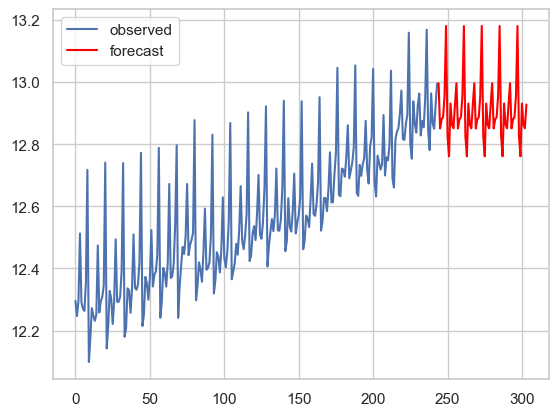

In [54]:
import matplotlib.pyplot as plt

plt.plot(df['y'], label='observed')
plt.plot(range(len(df), len(df) + 60), fc_vals, label='forecast', color='red')
plt.legend()
plt.show()

# 線形トレンド

In [55]:
import numpy as np
import statsmodels.api as sm

class LocalLinearTrendSeasonalModel(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 周期12の季節性
    """
    param_names = ['obs_error','level_noise','slope_noise','seasonal_noise']
    positive_params = [0,1,2,3]
    start_params = [0.01,0.01,0.001,0.001]
    k_posdef = 3  # level, slope, seasonal の誤差

    def __init__(self, endog):
        # 状態数 = 2 (level,slope) + 11 (seasonal) = 13
        super().__init__(endog=endog, k_states=13, k_posdef=self.k_posdef, initialization='diffuse')

        # design 
        self.ssm['design'] = np.zeros((1,13))
        self.ssm['design',0,0] = 1  # level
        self.ssm['design',0,2] = 1  # seasonal first component

        # transition
        T = np.zeros((13,13))
        # level-slope block
        T[0,0], T[0,1] = 1, 1
        T[1,1] = 1
        # seasonal sum-to-zero
        T[2,2:] = -1
        for i in range(3,13):
            T[i,i-1] = 1
        self.ssm['transition'] = T

        # selection
        S = np.zeros((13,3))
        S[0,0] = 1  # level noise
        S[1,1] = 1  # slope noise
        S[2,2] = 1  # seasonal noise
        self.ssm['selection'] = S

    def transform_params(self, unconstrained):
        c = unconstrained.copy()
        c[self.positive_params] = c[self.positive_params]**2
        return c

    def untransform_params(self, constrained):
        u = constrained.copy()
        u[self.positive_params] = constrained[self.positive_params]**0.5
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        # 観測誤差
        self['obs_cov',0,0]   = params[0]
        # state noise
        self['state_cov',0,0] = params[1]
        self['state_cov',1,1] = params[2]
        self['state_cov',2,2] = params[3]

In [56]:
# モデルのデータ準備
endog = df['y']

# モデルのインスタンス化
model = LocalLinearTrendSeasonalModel(
    endog=endog,
)

# モデルのフィッティング
result_linear= model.fit(disp=False)
print(result_linear.summary())

                                 Statespace Model Results                                
Dep. Variable:                                 y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalModel   Log Likelihood                 469.451
Date:                           Sun, 25 Jan 2026   AIC                           -904.902
Time:                                   15:12:31   BIC                           -845.450
Sample:                                        0   HQIC                          -880.958
                                           - 244                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
obs_error          0.0002   4.94e-05      4.711      0.000       0.000       0.000
level_noise        0.0001   2.9

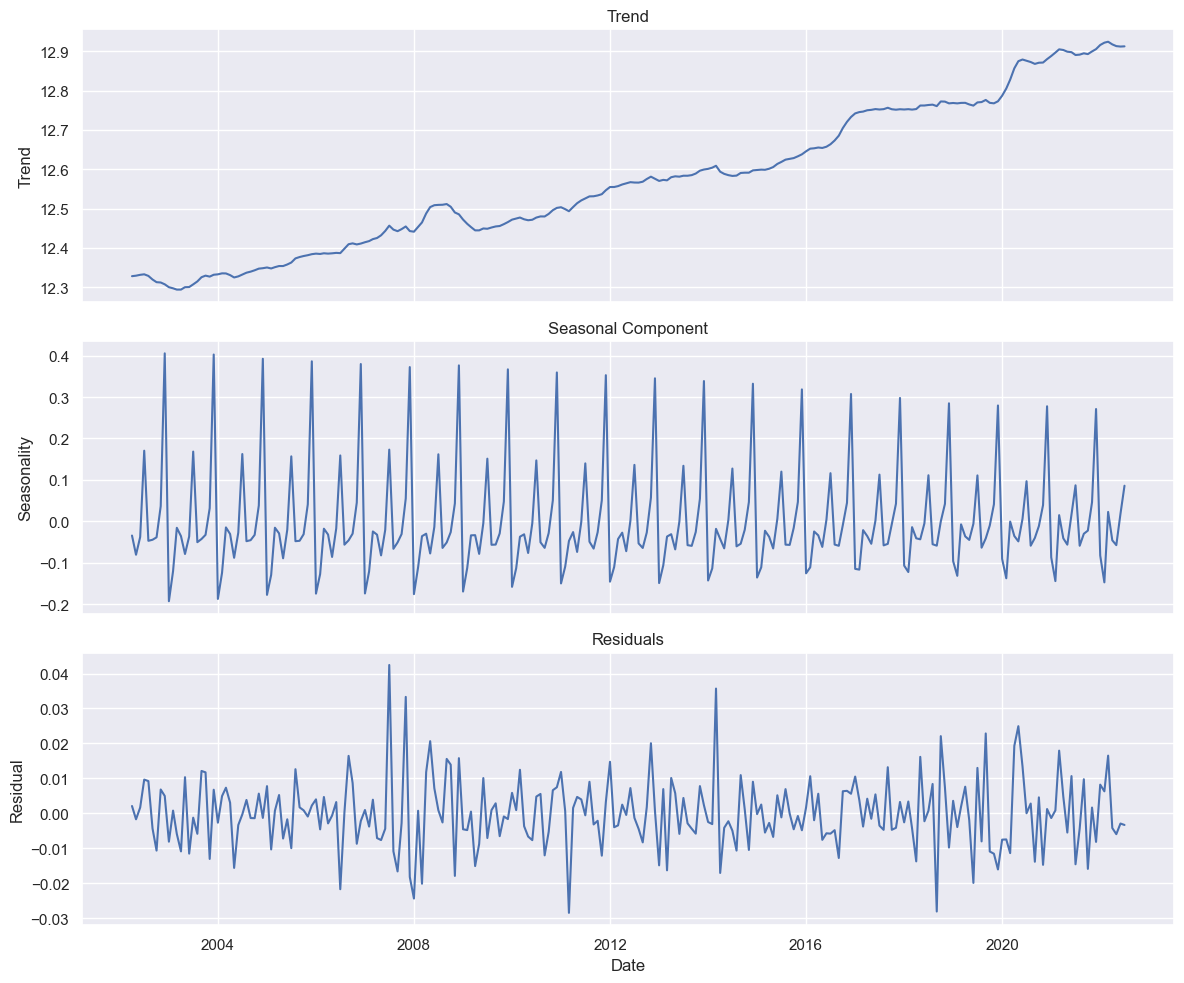

In [57]:
smoothed = result_linear.smoother_results
trend_smoothed = smoothed.smoothed_state[0]
seasonal_smoothed = smoothed.smoothed_state[2]

# （トレンド + 季節性）
reconstructed = trend_smoothed + seasonal_smoothed

# 残差
residuals = df['y'].values - reconstructed

sns.set_style('darkgrid')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# トレンド
sns.lineplot(x=df['label'], y=trend_smoothed, ax=axes[0])
axes[0].set_title('Trend')
axes[0].set_ylabel('Trend')

# 季節成分
sns.lineplot(x=df['label'], y=seasonal_smoothed, ax=axes[1])
axes[1].set_title('Seasonal Component')
axes[1].set_ylabel('Seasonality')

# 残差
sns.lineplot(x=df['label'], y=residuals, ax=axes[2])
axes[2].set_title('Residuals')
axes[2].set_ylabel('Residual')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [58]:
import plotly.graph_objects as go
import plotly.io as pio

# x軸
x = df['label']

# 各系列のトレース
fig = go.Figure()

# トレンド
fig.add_trace(go.Scatter(x=x, y=trend_smoothed, mode='lines', name='Trend'))

# 季節成分
fig.add_trace(go.Scatter(x=x, y=seasonal_smoothed, mode='lines', name='Seasonality'))

# 残差
fig.add_trace(go.Scatter(x=x, y=residuals, mode='lines', name='Residual'))

fig.update_layout(
    title='Trend, Seasonal Component, Residuals',
    xaxis_title='Date',
    yaxis_title='Value',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99, bordercolor="Black", borderwidth=1),
    height=500
)

fig.show()

#pio.write_html(fig, file='output_plot.html', auto_open=False)

In [59]:
smoothed_states = result_linear.smoothed_state  # shape = (k_states, T)
smoothed_trend = smoothed_states[0]
smoothed_seasonal = smoothed_states[1]

def forecast_mlemodel(res, steps=36):
    transition = res.model.ssm['transition']
    design     = res.model.ssm['design']
    # 最終時点の平滑化状態を初期化
    state = res.smoothed_state[:, -1].copy()
    forecasts = []

    for _ in range(steps):
        # 観測の点予測
        forecasts.append(float(design @ state))
        # 状態を1ステップ進める
        state = transition @ state

    return np.array(forecasts)

# まず transition を修正してから再フィット or update してください
# その上で
fc_vals = forecast_mlemodel(result_base, steps=36)
fc_vals

C:\Users\fugat\AppData\Local\Temp\ipykernel_51932\2539698982.py:14: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



array([12.99656648, 12.85069636, 12.87985025, 12.88722647, 12.95616204,
       13.18060647, 12.82681786, 12.76096929, 12.93113486, 12.86237679,
       12.85119267, 12.92776734, 12.99656648, 12.85069636, 12.87985025,
       12.88722647, 12.95616204, 13.18060647, 12.82681786, 12.76096929,
       12.93113486, 12.86237679, 12.85119267, 12.92776734, 12.99656648,
       12.85069636, 12.87985025, 12.88722647, 12.95616204, 13.18060647,
       12.82681786, 12.76096929, 12.93113486, 12.86237679, 12.85119267,
       12.92776734])

In [60]:
df_plot = df.copy()
df_plot['label'] = pd.to_datetime(df_plot['label'])
df_plot.set_index('label', inplace=True)
steps = 36

# --- 信頼区間の計算 ---
P = result_base.smoothed_state_cov[:, :, -1]
Q = model.ssm['state_cov']
T = model.ssm['transition']
design = model.ssm['design']
obs_var = model.ssm['obs_cov'][0, 0]

# Q を full サイズに拡張
Q_full = np.zeros_like(P)
Q_full[:Q.shape[0], :Q.shape[1]] = Q

forecast_var = []
for _ in range(steps):
    P = T @ P @ T.T + Q_full
    var_y = (design @ P @ design.T)[0, 0] + obs_var
    forecast_var.append(var_y)


forecast_var = np.array(forecast_var)
ci_lower = fc_vals - 1.96 * np.sqrt(forecast_var)
ci_upper = fc_vals + 1.96 * np.sqrt(forecast_var)

# --- 予測用データフレーム作成 ---
fc_df = pd.DataFrame({
    'mean': fc_vals,
    'lower': ci_lower,
    'upper': ci_upper
})
start = df_plot.index[-1] + pd.offsets.MonthBegin(1)
future_idx = pd.date_range(start=start, periods=steps, freq='MS')
fc_df.index = future_idx

# --- プロット ---
sns.set_style('darkgrid')
sns.set_context('notebook', font_scale=0.9)  # ← フォントサイズ小さめ

plt.figure(figsize=(10, 6))

# 実測値
sns.lineplot(
    x=df_plot.index,
    y=df_plot['y'],
    label='Observed',
    color='darkslategray',
    lw=0.8
)

# 予測平均
sns.lineplot(
    x=fc_df.index,
    y=fc_df['mean'],
    label='Forecast',
    color='blue',
    lw=0.8,
)

# 信頼区間 (95%)
plt.fill_between(
    fc_df.index,
    fc_df['lower'],
    fc_df['upper'],
    color='blue',
    alpha=0.1
)

# 軸と凡例
plt.xlabel('Date', fontsize=10)
plt.ylabel('Log-transformed Parcel Count', fontsize=10)
plt.title('Observed, Forecast', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 12 is different from 13)

In [ ]:
steps

60

## 外生変数の導入

### リーマンショック

In [ ]:
# リーマンショック
class LocalLinearTrendSeasonalWithShock(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 周期12の季節性 + リーマンショック外生変数
    """
    param_names = ['obs_error', 'level_noise', 'slope_noise', 'seasonal_noise', 'shock_effect']
    positive_params = [0, 1, 2, 3]
    start_params = [0.01, 0.01, 0.001, 0.001, 0.0]
    k_posdef = 3

    def __init__(self, endog, exog):  # exog: shock dummy vector
        super().__init__(endog=endog, k_states=13, k_posdef=self.k_posdef, initialization='diffuse')

        # design matrix
        self.ssm['design'] = np.zeros((1, 13))
        self.ssm['design', 0, 0] = 1  # level
        self.ssm['design', 0, 2] = 1  # seasonal (first)

        # transition matrix
        T = np.zeros((13, 13))
        T[0, 0], T[0, 1] = 1, 1
        T[1, 1] = 1
        T[2, 2:] = -1
        for i in range(3, 13):
            T[i, i - 1] = 1
        self.ssm['transition'] = T

        # selection matrix
        S = np.zeros((13, 3))
        S[0, 0] = 1  # level
        S[1, 1] = 1  # slope
        S[2, 2] = 1  # seasonal
        self.ssm['selection'] = S

        # 外生変数（事変係数）を観測切片として導入
        self.exog = exog.values.reshape(1, -1)  # shape: (1, T)
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

    def transform_params(self, unconstrained):
        c = unconstrained.copy()
        c[self.positive_params] = c[self.positive_params] ** 2
        return c

    def untransform_params(self, constrained):
        u = constrained.copy()
        u[self.positive_params] = np.sqrt(u[self.positive_params])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self['obs_cov', 0, 0] = params[0]
        self['state_cov', 0, 0] = params[1]
        self['state_cov', 1, 1] = params[2]
        self['state_cov', 2, 2] = params[3]
        self['obs_intercept', 0, :] = params[4] * self.exog


In [ ]:
shock_dummy = ((df['label'] >= '2008-09-01') & (df['label'] <= '2009-04-30')).astype(int)
model = LocalLinearTrendSeasonalWithShock(endog=df['y'], exog=shock_dummy)
result_with_shock = model.fit()
print(result_with_shock.summary())

                                   Statespace Model Results                                  
Dep. Variable:                                     y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithShock   Log Likelihood                 469.473
Date:                               Mon, 30 Jun 2025   AIC                           -902.947
Time:                                       13:51:15   BIC                           -839.998
Sample:                                            0   HQIC                          -877.594
                                               - 244                                         
Covariance Type:                                 opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
obs_error          0.0002   5.16e-05      4.505      0.000       0.000       0.000

### 運賃値上げ

In [ ]:
class LocalLinearTrendSeasonalWithPriceHike(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 周期12の季節性 + 配送料値上げの外生変数
    """
    param_names = ['obs_error', 'level_noise', 'slope_noise', 'seasonal_noise', 'price_hike_effect']
    positive_params = [0, 1, 2, 3]
    start_params = [0.01, 0.01, 0.001, 0.001, 0.0]
    k_posdef = 3

    def __init__(self, endog, exog):  # exog: 値上げ期間のダミー
        super().__init__(endog=endog, k_states=13, k_posdef=self.k_posdef, initialization='diffuse')

        # design matrix
        self.ssm['design'] = np.zeros((1, 13))
        self.ssm['design', 0, 0] = 1  # level
        self.ssm['design', 0, 2] = 1  # seasonal (first)

        # transition matrix
        T = np.zeros((13, 13))
        T[0, 0], T[0, 1] = 1, 1
        T[1, 1] = 1
        T[2, 2:] = -1
        for i in range(3, 13):
            T[i, i - 1] = 1
        self.ssm['transition'] = T

        # selection matrix
        S = np.zeros((13, 3))
        S[0, 0] = 1  # level
        S[1, 1] = 1  # slope
        S[2, 2] = 1  # seasonal
        self.ssm['selection'] = S

        # 外生変数を観測切片として導入
        self.exog = exog.values.reshape(1, -1)
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

    def transform_params(self, unconstrained):
        c = unconstrained.copy()
        c[self.positive_params] = c[self.positive_params] ** 2
        return c

    def untransform_params(self, constrained):
        u = constrained.copy()
        u[self.positive_params] = np.sqrt(u[self.positive_params])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self['obs_cov', 0, 0] = params[0]
        self['state_cov', 0, 0] = params[1]
        self['state_cov', 1, 1] = params[2]
        self['state_cov', 2, 2] = params[3]
        self['obs_intercept', 0, :] = params[4] * self.exog


In [ ]:
price_hike_dummy = ((df['label'] >= '2017-10-01') & (df['label'] <= '2019-12-31')).astype(int)
model = LocalLinearTrendSeasonalWithPriceHike(endog=df['y'], exog=price_hike_dummy)
result_with_price_hike = model.fit()
print(result_with_price_hike.summary())


                                     Statespace Model Results                                    
Dep. Variable:                                         y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithPriceHike   Log Likelihood                 471.703
Date:                                   Tue, 02 Dec 2025   AIC                           -907.407
Time:                                           17:11:41   BIC                           -844.458
Sample:                                                0   HQIC                          -882.054
                                                   - 244                                         
Covariance Type:                                     opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
obs_error             0.0002   4.89e-05     

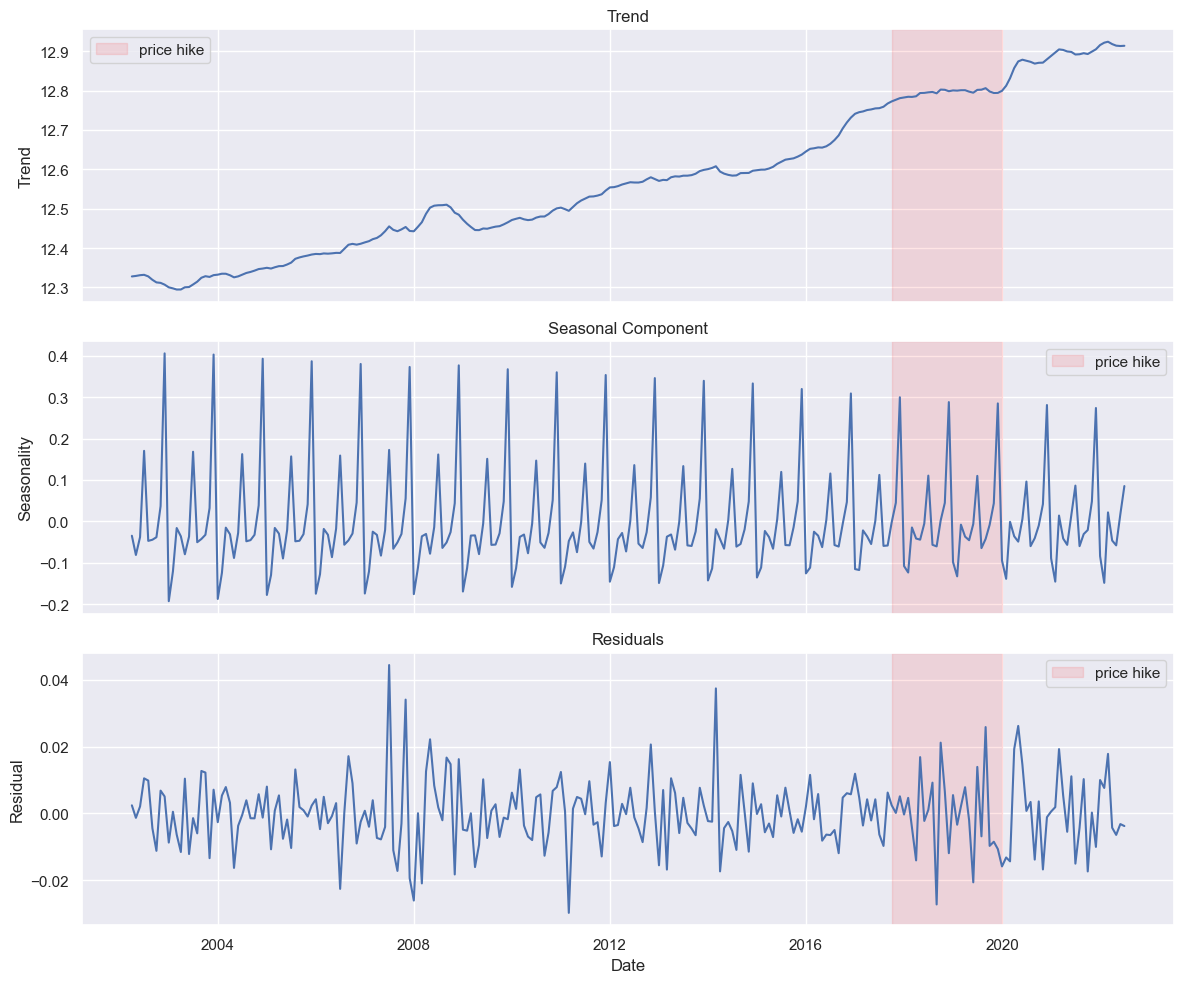

In [ ]:
smoothed = result_with_price_hike.smoother_results
trend_smoothed_hike = smoothed.smoothed_state[0]
seasonal_smoothed_hike = smoothed.smoothed_state[2]

beta = result_with_price_hike.params['price_hike_effect']
x = price_hike_dummy.values

residuals_hike = df['y'].values - (trend_smoothed_hike + seasonal_smoothed_hike + beta * x)

sns.set_style('darkgrid')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

highlight_start = pd.to_datetime('2017-10-01')
highlight_end = pd.to_datetime('2019-12-31')

# すべてのグラフに対して追加
for ax in axes:
    ax.axvspan(highlight_start, highlight_end, color='red', alpha=0.1, label='price hike')
    ax.legend()

# トレンド
sns.lineplot(x=df['label'], y=trend_smoothed_hike, ax=axes[0])
axes[0].set_title('Trend')
axes[0].set_ylabel('Trend')

# 季節成分
sns.lineplot(x=df['label'], y=seasonal_smoothed_hike, ax=axes[1])
axes[1].set_title('Seasonal Component')
axes[1].set_ylabel('Seasonality')

# 残差
sns.lineplot(x=df['label'], y=residuals_hike, ax=axes[2])
axes[2].set_title('Residuals')
axes[2].set_ylabel('Residual')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()

# トレンド＋季節成分＋値上げ効果
fig.add_trace(go.Scatter(
    x=df['label'], y=trend_smoothed_hike + seasonal_smoothed_hike + beta * price_hike_dummy,
    mode='lines', name='Trend + Seasonal + Price Hike Effect',
    line=dict(color='red')
))

# 観測値
fig.add_trace(go.Scatter(
    x=df['label'], y=df['y'],
    mode='lines', name='Observed',
    line=dict(color='black')
))

# トレンド
fig.add_trace(go.Scatter(
    x=df['label'], y=trend_smoothed_hike,
    mode='lines', name='Trend',
    line=dict(color='blue')
))

# 季節成分
fig.add_trace(go.Scatter(
    x=df['label'], y=seasonal_smoothed_hike,
    mode='lines', name='Seasonal Component',
    line=dict(color='green')
))

# 残差
fig.add_trace(go.Scatter(
    x=df['label'], y=residuals_hike,
    mode='lines', name='Residuals',
    line=dict(color='orange')
))

fig.add_vrect(x0="2017-10-01", x1="2019-12-31",
              fillcolor="LightSalmon", opacity=0.2, line_width=0,
              annotation_text="宅配便各社運賃値上げ", annotation_position="top left")

fig.update_layout(
    title="宅配便運賃値上げの外生変数導入版",
    xaxis_title="Date",
    yaxis_title="Value",
    legend=dict(x=0.01, y=0.99),
    template="plotly_white",
    height=600
)

fig.show()
pio.write_html(fig, file='output_plot2.html', auto_open=True)

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio

# ---- トレンド比較 ----
fig_trend = go.Figure()

# 新モデルのトレンド
fig_trend.add_trace(go.Scatter(
    x=df['label'], y=trend_smoothed_hike,
    mode='lines', name='Trend (with Price Hike)',
    line=dict(color='blue')
))

# 従来モデルのトレンド
fig_trend.add_trace(go.Scatter(
    x=df['label'], y=trend_smoothed,
    mode='lines', name='Trend (original)',
    line=dict(color='red', dash='dot')
))

fig_trend.update_layout(
    title="トレンドの比較",
    xaxis_title="Date",
    yaxis_title="Trend",
    legend=dict(x=0.01, y=0.99),
    template="plotly_white",
    height=500
)

fig_trend.show()
pio.write_html(fig_trend, file='trend_comparison.html', auto_open=False)


# ---- 残差比較 ----
fig_residual = go.Figure()

# 新モデルの残差
fig_residual.add_trace(go.Scatter(
    x=df['label'], y=residuals_hike,
    mode='lines', name='Residuals (with Price Hike)',
    line=dict(color='orange')
))

# 従来モデルの残差
fig_residual.add_trace(go.Scatter(
    x=df['label'], y=residuals,
    mode='lines', name='Residuals (original)',
    line=dict(color='gray', dash='dot')
))

fig_residual.update_layout(
    title="残差の比較",
    xaxis_title="Date",
    yaxis_title="Residual",
    legend=dict(x=0.01, y=0.99),
    template="plotly_white",
    height=500
)

fig_residual.show()
pio.write_html(fig_residual, file='residual_comparison.html', auto_open=True)


### 宅配便値上げ(駆け込みあり)

In [ ]:
# 2つの固定係数を持つモデルクラス
class LocalLinearTrendSeasonalWithPriceHikeAndPreHike(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 季節性 + 2つの外生変数（値上げ後, 駆け込み）
    """
    # CHANGED: パラメータに 'pre_hike_effect' を追加
    param_names = ['obs_error', 'level_noise', 'slope_noise', 'seasonal_noise', 
                   'price_hike_effect', 'pre_hike_effect']
    positive_params = [0, 1, 2, 3]
    start_params = [0.01, 0.01, 0.001, 0.001, 0.0, 0.0]
    k_posdef = 3

    # CHANGED: 2つの外生変数 exog1, exog2 を受け取る
    def __init__(self, endog, exog1, exog2):
        # 状態に関する部分は変更なし
        super().__init__(endog=endog, k_states=13, k_posdef=self.k_posdef, initialization='diffuse')

        # design, transition, selection 行列は変更なし
        # design matrix
        self.ssm['design'] = np.zeros((1, 13))
        self.ssm['design', 0, 0] = 1
        self.ssm['design', 0, 2] = 1

        # transition matrix
        T = np.zeros((13, 13))
        T[0, 0], T[0, 1] = 1, 1
        T[1, 1] = 1
        T[2, 2:] = -1
        for i in range(3, 13):
            T[i, i - 1] = 1
        self.ssm['transition'] = T

        # selection matrix
        S = np.zeros((13, 3))
        S[0, 0] = 1
        S[1, 1] = 1
        S[2, 2] = 1
        self.ssm['selection'] = S

        # NEW: 2つの外生変数を保持
        self.exog1 = exog1.values.reshape(1, -1) # 値上げ後ダミー
        self.exog2 = exog2.values.reshape(1, -1) # 駆け込みダミー
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

    def transform_params(self, unconstrained):
        c = unconstrained.copy()
        c[self.positive_params] = c[self.positive_params] ** 2
        return c

    def untransform_params(self, constrained):
        u = constrained.copy()
        u[self.positive_params] = np.sqrt(u[self.positive_params])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self['obs_cov', 0, 0] = params[0]
        self['state_cov', 0, 0] = params[1]
        self['state_cov', 1, 1] = params[2]
        self['state_cov', 2, 2] = params[3]
        
        # CHANGED: 観測切片を2つの効果の合計として計算
        self['obs_intercept', 0, :] = params[4] * self.exog1 + params[5] * self.exog2

In [ ]:
# 1. 値上げ後ダミー変数 (既存)
price_hike_dummy = ((df['label'] >= '2017-10-01') & (df['label'] <= '2019-12-31')).astype(int)

# 2. 駆け込み需要ダミー変数 (新規)
# 発表(4月末)の翌月から実施(10月)の前月まで
pre_hike_dummy = ((df['label'] >= '2017-09-01') & (df['label'] <= '2017-09-30')).astype(int)

# 3. モデルのインスタンス化と学習
model_with_pre_hike = LocalLinearTrendSeasonalWithPriceHikeAndPreHike(
    endog=df['y'], 
    exog1=price_hike_dummy, 
    exog2=pre_hike_dummy
)
result_with_pre_hike = model_with_pre_hike.fit(maxiter=1000) # maxiterを増やすと収束しやすくなります

# 4. 結果の表示と比較
print("--- 駆け込み需要を追加したモデルの結果 ---")
print(result_with_pre_hike.summary())

print("\n--- AICの比較 ---")
print(f"前回のベストモデル（値上げ効果のみ）のAIC: -907.407")
print(f"今回のモデル（値上げ＋駆け込み）のAIC:   {result_with_pre_hike.aic:.3f}")

--- 駆け込み需要を追加したモデルの結果 ---
                                          Statespace Model Results                                         
Dep. Variable:                                                   y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithPriceHikeAndPreHike   Log Likelihood                 471.902
Date:                                             Mon, 30 Jun 2025   AIC                           -905.804
Time:                                                     13:51:16   BIC                           -839.358
Sample:                                                          0   HQIC                          -879.043
                                                             - 244                                         
Covariance Type:                                               opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------

c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



### コロナによる宅配便需要

In [ ]:
# 固定係数と時変係数を両方持つモデルクラス
class LocalLinearTrendSeasonalWithFixedAndTVExog(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 季節性 + 固定係数の外生変数1 + 時変係数の外生変数2
    """
    # CHANGED: パラメータ名を固定係数と時変係数の誤差の両方を含むように変更
    param_names = ['obs_error', 'level_noise', 'slope_noise', 'seasonal_noise', 
                   'fixed_effect_coef',  # exog1 (値上げ効果)
                   'tv_effect_noise']   # exog2 (コロナ禍効果の誤差)
    
    positive_params = [0, 1, 2, 3, 5] # 誤差分散と固定係数でないものを除く
    start_params = [0.01, 0.01, 0.001, 0.001, 0.0, 0.001]
    
    # CHANGED: 状態誤差の数が4に (level, slope, seasonal, tv_effect)
    k_posdef = 4

    def __init__(self, endog, exog_fixed, exog_tv):
        # CHANGED: 状態数が14に (元の13 + 時変係数)
        super().__init__(endog=endog, k_states=14, k_posdef=self.k_posdef, initialization='diffuse')

        # --- 行列の設定 ---
        # NEW: 2種類の外生変数を保持
        self.exog_fixed = exog_fixed.values
        self.exog_tv = exog_tv.values

        # design matrix (時変)
        self.ssm['design'] = np.zeros((1, 14, self.nobs))
        self.ssm['design', 0, 0, :] = 1  # level
        self.ssm['design', 0, 2, :] = 1  # seasonal
        self.ssm['design', 0, 13, :] = self.exog_tv # 時変係数の外生変数

        # transition matrix (14x14)
        T = np.zeros((14, 14))
        T[0, 0], T[0, 1] = 1, 1
        T[1, 1] = 1
        T[2, 2:] = -1
        for i in range(3, 13):
            T[i, i - 1] = 1
        T[13, 13] = 1  # 時変係数はランダムウォーク
        self.ssm['transition'] = T

        # selection matrix (14x4)
        S = np.zeros((14, 4))
        S[0, 0] = 1; S[1, 1] = 1; S[2, 2] = 1
        S[13, 3] = 1 # 時変係数の誤差
        self.ssm['selection'] = S

        # NEW: 観測切片を固定係数のために用意
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

    def transform_params(self, unconstrained):
        c = unconstrained.copy()
        c[self.positive_params] = c[self.positive_params] ** 2
        return c

    def untransform_params(self, constrained):
        u = constrained.copy()
        u[self.positive_params] = np.sqrt(u[self.positive_params])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        # 誤差の分散
        self['obs_cov', 0, 0] = params[0]
        self['state_cov', 0, 0] = params[1]
        self['state_cov', 1, 1] = params[2]
        self['state_cov', 2, 2] = params[3]
        self['state_cov', 3, 3] = params[5] # tv_effect_noise

        # 固定係数の設定
        self['obs_intercept', 0, :] = params[4] * self.exog_fixed

In [ ]:
# 1. 値上げ後ダミー変数 (固定係数用)
price_hike_dummy = ((df['label'] >= '2017-10-01') & (df['label'] <= '2019-12-31')).astype(int)

# 2. コロナ禍ダミー変数 (時変係数用)
# 日本で影響が顕在化した2020年3月以降とする
corona_dummy = (df['label'] >= '2020-03-01').astype(int)

# 3. モデルのインスタンス化と学習
model_hybrid = LocalLinearTrendSeasonalWithFixedAndTVExog(
    endog=df['y'],
    exog_fixed=price_hike_dummy,
    exog_tv=corona_dummy
)
result_hybrid = model_hybrid.fit(maxiter=1000)

# 4. 結果の表示と比較
print("--- 固定係数(値上げ)＋時変係数(コロナ禍)モデルの結果 ---")
print(result_hybrid.summary())

print("\n--- AICの比較 ---")
print(f"前回のベストモデル（値上げ効果のみ）のAIC: -907.407")
print(f"今回のハイブリッドモデルのAIC:          {result_hybrid.aic:.3f}")

--- 固定係数(値上げ)＋時変係数(コロナ禍)モデルの結果 ---
                                       Statespace Model Results                                       
Dep. Variable:                                              y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithFixedAndTVExog   Log Likelihood                 474.912
Date:                                        Mon, 30 Jun 2025   AIC                           -909.824
Time:                                                13:51:16   BIC                           -839.881
Sample:                                                     0   HQIC                          -881.655
                                                        - 244                                         
Covariance Type:                                          opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
smoothed_hybrid = result_hybrid.smoother_results
trend_smoothed = smoothed_hybrid.smoothed_state[0]
seasonal_smoothed = smoothed_hybrid.smoothed_state[2]
beta_hike = result_hybrid.params['fixed_effect_coef']
price_hike_effect = beta_hike * price_hike_dummy
covid_effect_coef_t = smoothed_hybrid.smoothed_state[13]
corona_effect = covid_effect_coef_t * corona_dummy
fitted_values = trend_smoothed + seasonal_smoothed + price_hike_effect + corona_effect
residuals_hybrid = df['y'].values - fitted_values


palette = px.colors.qualitative.Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=df['label'], y=df['y'], name='Observed (観測値)', line=dict(color='dimgray', width=2)))
fig.add_trace(go.Scatter(x=df['label'], y=trend_smoothed, name='Trend', line=dict(color='royalblue', width=2.5)))
fig.add_trace(go.Scatter(x=df['label'], y=seasonal_smoothed, name='Seasonal', line=dict(color=palette[2])))
fig.add_trace(go.Scatter(x=df['label'], y=price_hike_effect, name='Price Hike Effect', line=dict(color=palette[4])))
fig.add_trace(go.Scatter(x=df['label'], y=corona_effect, name='COVID-19 Effect', line=dict(color=palette[3])))
fig.add_trace(go.Scatter(x=df['label'], y=residuals_hybrid, name='Residuals', mode='lines', line=dict(color=palette[5], dash='dot')))
fig.add_trace(go.Scatter(x=df['label'], y=fitted_values, name='Fitted (モデル予測値)', mode='lines', line=dict(color='red', width=2, dash='dash')))


fig.add_vrect(x0="2017-10-01", x1="2019-12-31", fillcolor="LightSalmon", opacity=0.2, line_width=0,
              annotation_text="宅配便値上げ", annotation_position="top left")
fig.add_vrect(x0="2020-03-01", x1=df['label'].iloc[-1].strftime('%Y-%m-%d'), 
              fillcolor="LightSkyBlue", opacity=0.2, line_width=0,
              annotation_text="コロナ禍", annotation_position="top left")

fig.update_layout(
    title_text="宅配便値上げ(固定係数)とコロナ禍(時変係数)",
    xaxis_title="Date",
    yaxis_title="Value (log scale)",
    template="plotly_white",
    height=600,
    legend=dict(x=0.01, y=0.99)
)

fig.show()
pio.write_html(fig, file='output_plot_4.html', auto_open=False)

In [ ]:
result_hybrid.params['tv_effect_noise']

np.float64(5.034751768210934e-05)

テスト

In [ ]:
df['rush_delivery'] = ((df['label'] >= '2017-07-01') & (df['label'] <= '2017-09-01')).astype(int)
df['delivery_price_up'] = ((df['label'] >= '2017-10-01') & (df['label'] <= '2019-12-01')).astype(int)

exog_df = df[['label', 'rush_delivery', 'delivery_price_up']]
exog_df

,label,rush_delivery,delivery_price_up
0,2002-04-01,0,0
1,2002-05-01,0,0
2,2002-06-01,0,0
3,2002-07-01,0,0
4,2002-08-01,0,0
...,...,...,...
239,2022-03-01,0,0
240,2022-04-01,0,0
241,2022-05-01,0,0
242,2022-06-01,0,0


### 値上げ(固定)＋コロナ禍フェーズ分け(固定)モデル

In [ ]:
# (1) 値上げダミー
hike_dummy = ((df['label'] >= '2017-10-01') & (df['label'] <= '2019-12-31')).astype(int)

# (2) コロナ禍ダミー（フェーズ分け）
# 構造的な底上げ効果
covid_main = (df['label'] >= '2020-03-01').astype(int)
# 第1波の急増効果
covid_wave1 = ((df['label'] >= '2020-04-01') & (df['label'] <= '2020-05-31')).astype(int)
# 2021年の主要な宣言期
covid_2021 = ((df['label'] >= '2021-01-01') & (df['label'] <= '2021-09-30')).astype(int)
covid_2021 = ((df['label'] >= '2021-01-01') & (df['label'] <= '2021-09-30')).astype(int)

In [62]:
import statsmodels.api as sm

class LocalLinearTrendSeasonalWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 季節性 + 複数の固定係数の外生変数
    """
    def __init__(self, endog, exog_list, param_names, **kwargs):
        k_states = 13
        k_posdef = 3
        
        self.param_names_custom = param_names
        self.num_exog = len(exog_list)
        
        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization='diffuse', **kwargs)

        self.ssm['design'] = np.zeros((1, k_states))
        self.ssm['design', 0, 0] = 1; self.ssm['design', 0, 2] = 1
        T = np.zeros((k_states, k_states)); T[0, 0], T[0, 1] = 1, 1; T[1, 1] = 1
        T[2, 2:] = -1
        for i in range(3, k_states): T[i, i - 1] = 1
        self.ssm['transition'] = T
        S = np.zeros((k_states, k_posdef)); S[0, 0] = 1; S[1, 1] = 1; S[2, 2] = 1
        self.ssm['selection'] = S

        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        c = unconstrained.copy(); c[:4] = c[:4] ** 2 
        return c

    def untransform_params(self, constrained):
        u = constrained.copy(); u[:4] = np.sqrt(u[:4])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self['obs_cov', 0, 0] = params[0]
        self['state_cov', 0, 0] = params[1]
        self['state_cov', 1, 1] = params[2]
        self['state_cov', 2, 2] = params[3]
        
        total_exog_effect = 0
        for i in range(self.num_exog):
            total_exog_effect += params[4 + i] * self.exogs[i]
        self['obs_intercept', 0, :] = total_exog_effect

In [63]:
exog_vars = [hike_dummy, covid_main, covid_wave1, covid_2021]

# モデルのパラメータ名
model_param_names = [
    'obs_error', 'level_noise', 'slope_noise', 'seasonal_noise',
    'hike_effect', 'covid_main_effect', 'covid_wave1_effect', 'covid_2021_effect'
]

# モデルのインスタンス化
model_phase = LocalLinearTrendSeasonalWithMultiFixedExog(
    endog=df['y'],
    exog_list=exog_vars,
    param_names=model_param_names
)
start_params_for_model = [0.01, 0.01, 0.001, 0.001, 0.0, -2.0, -2.0, -3.0]
result_phase = model_phase.fit(start_params=start_params_for_model, maxiter=1000)

print("--- コロナ禍フェーズ分けモデルの結果 ---")
print(result_phase.summary())

print("\n--- AICの比較 ---")
print(f"現在のベストモデル（コロナ禍時変係数）のAIC: -909.824")
print(f"今回のフェーズ分け固定係数モデルのAIC:      {result_phase.aic:.3f}")

--- コロナ禍フェーズ分けモデルの結果 ---
                                       Statespace Model Results                                       
Dep. Variable:                                              y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithMultiFixedExog   Log Likelihood                 480.943
Date:                                        Sun, 25 Jan 2026   AIC                           -919.886
Time:                                                15:13:42   BIC                           -846.445
Sample:                                                     0   HQIC                          -890.308
                                                        - 244                                         
Covariance Type:                                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [64]:
smoothed_phase = result_phase.smoother_results
trend_smoothed = smoothed_phase.smoothed_state[0]
seasonal_smoothed = smoothed_phase.smoothed_state[2]
beta_hike = result_phase.params['hike_effect']
hike_effect_full = beta_hike * hike_dummy
beta_covid_main = result_phase.params['covid_main_effect']
covid_main_effect_full = beta_covid_main * covid_main
beta_covid_wave1 = result_phase.params['covid_wave1_effect']
covid_wave1_effect_full = beta_covid_wave1 * covid_wave1
beta_covid_2021 = result_phase.params['covid_2021_effect']
covid_2021_effect_full = beta_covid_2021 * covid_2021
fitted_values = (trend_smoothed + seasonal_smoothed + hike_effect_full + 
                 covid_main_effect_full + covid_wave1_effect_full + covid_2021_effect_full)
residuals_phase = df['y'].values - fitted_values


palette = px.colors.qualitative.Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=df['label'], y=df['y'], name='Observed (観測値)', line=dict(color='dimgray', width=2)))
fig.add_trace(go.Scatter(x=df['label'], y=trend_smoothed, name='Trend', line=dict(color='royalblue', width=2.5)))
fig.add_trace(go.Scatter(x=df['label'], y=seasonal_smoothed, name='Seasonal', line=dict(color=palette[2])))
fig.add_trace(go.Scatter(x=df['label'], y=hike_effect_full, name='Hike Effect', line=dict(color=palette[4])))
fig.add_trace(go.Scatter(x=df['label'], y=covid_main_effect_full, name='COVID Main Effect', line=dict(color=palette[3])))
fig.add_trace(go.Scatter(x=df['label'], y=covid_wave1_effect_full, name='COVID Wave 1 Effect', line=dict(color=palette[9])))
fig.add_trace(go.Scatter(x=df['label'], y=covid_2021_effect_full, name='COVID 2021 Effect', line=dict(color=palette[6])))
fig.add_trace(go.Scatter(x=df['label'], y=residuals_phase, name='Residuals', mode='lines', line=dict(color=palette[5], dash='dot')))
fig.add_trace(go.Scatter(x=df['label'], y=fitted_values, name='Fitted (モデル予測値)', mode='lines', line=dict(color='red', width=2, dash='dash')))

fig.add_vrect(x0="2017-10-01", x1="2019-12-31", fillcolor="LightSalmon", opacity=0.2, line_width=0, annotation_text="値上げ", annotation_position="top left")
fig.add_vrect(x0="2020-04-01", x1="2020-05-31", fillcolor="LightSkyBlue", opacity=0.3, line_width=0, annotation_text="コロナ第1波", annotation_position="top left")
fig.add_vrect(x0="2021-01-01", x1="2021-09-30", fillcolor="LightGreen", opacity=0.2, line_width=0, annotation_text="コロナ2021年", annotation_position="top left")

fig.update_layout(
    title_text="ハイパラ探索後の推定結果",
    xaxis_title="Date",
    yaxis_title="Value (log scale)",
    template="plotly_white",
    height=800, 
    legend=dict(x=0.01, y=0.99)
)

summary_text_detailed = """
<b>7/3進捗：外生変数に関するハイパラの検証</b><br>
<br>
前回は初期値の探索範囲が狭く, <br>
対数尤度にほとんど変化がなかった. <br>
→ モデルの推定結果が初期値に依存しないか確認するため, <br>
　 より広範な範囲でのグリッドサーチを実施した. 
"""

fig.add_annotation(
    text=summary_text_detailed,
    align='left',
    showarrow=False,
    xref='paper', 
    yref='paper',
    x=0.01,       
    y=0.01,       
    bgcolor="rgba(255, 255, 255, 0.8)", 
    bordercolor="black",
    borderwidth=1,

    # --- ここからが追加部分 ---
    font=dict(
        size=15,         # 文字の大きさを12ピクセルに設定
        color="black"      # 文字色を黒に設定
    )
)


fig.show()
pio.write_html(fig, file='output_plot_6.html', auto_open=False)

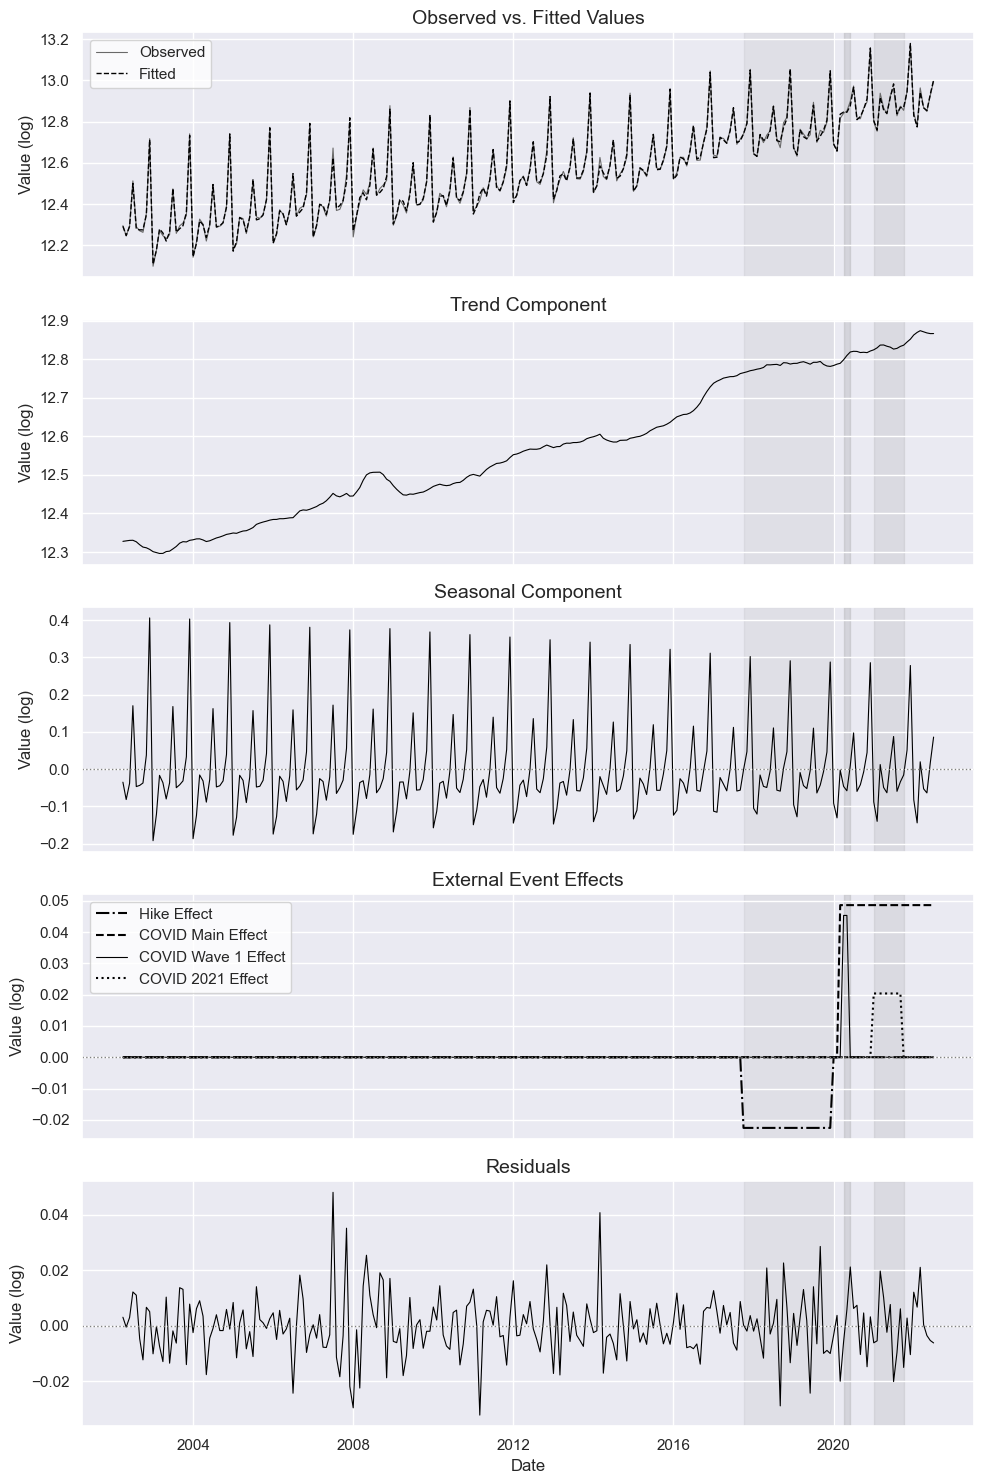

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- グラフの準備 ---
# 5つのグラフを縦に並べるための設定
# sharex=Trueで, 全グラフのX軸（時間軸）が連動する
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)
sns.set_theme(style="whitegrid")

# --- 1. 観測値とモデルのフィット ---
axes[0].plot(df['label'], df['y'], color='dimgray', label='Observed', linewidth=0.8)
axes[0].plot(df['label'], fitted_values, color='black', linestyle='--', label='Fitted', linewidth=1)
axes[0].set_title('Observed vs. Fitted Values', fontsize=14)
axes[0].legend(loc='upper left')

# --- 2. トレンド成分 ---
axes[1].plot(df['label'], trend_smoothed, color='black', label='Trend', lw=0.8)
axes[1].set_title('Trend Component', fontsize=14)
#axes[1].axhline(y=0, color='grey', linestyle=':', linewidth=1) # ゼロ基準線

# --- 3. 季節成分 ---
axes[2].plot(df['label'], seasonal_smoothed, color='black', label='Seasonal', lw=0.8)
axes[2].set_title('Seasonal Component', fontsize=14)
axes[2].axhline(y=0, color='grey', linestyle=':', linewidth=1) # ゼロ基準線

# --- 4. 外部イベント効果 ---
# 複数のイベント効果を線種を変えてプロット
axes[3].plot(df['label'], hike_effect_full, color='black', linestyle='-.', label='Hike Effect')
axes[3].plot(df['label'], covid_main_effect_full, color='black', linestyle='--', label='COVID Main Effect')
axes[3].plot(df['label'], covid_wave1_effect_full, color='black', linestyle='-', label='COVID Wave 1 Effect', linewidth=0.8)
axes[3].plot(df['label'], covid_2021_effect_full, color='black', linestyle=':', label='COVID 2021 Effect')
axes[3].set_title('External Event Effects', fontsize=14)
axes[3].axhline(y=0, color='grey', linestyle=':', linewidth=1) # ゼロ基準線
axes[3].legend(loc='upper left')

# --- 5. 残差 ---
axes[4].plot(df['label'], residuals_phase, color='black', linewidth=0.8, label='Residuals')
axes[4].set_title('Residuals', fontsize=14)
axes[4].axhline(y=0, color='grey', linestyle=':', linewidth=1) # ゼロ基準線

# --- 全グラフ共通の設定 ---
# 全てのサブプロットにイベント期間の背景色を追加
for ax in axes:
    ax.axvspan("2017-10-01", "2019-12-31", color='gray', alpha=0.1, zorder=-1)
    ax.axvspan("2020-04-01", "2020-05-31", color='gray', alpha=0.2, zorder=-1)
    ax.axvspan("2021-01-01", "2021-09-30", color='gray', alpha=0.15, zorder=-1)
    ax.set_ylabel('Value (log)')

# 最後のグラフにのみX軸のラベルを表示
axes[4].set_xlabel('Date', fontsize=12)

# レイアウトの自動調整
plt.tight_layout()

# グラフの表示と保存
plt.show()

In [73]:
!pip install japanize_matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


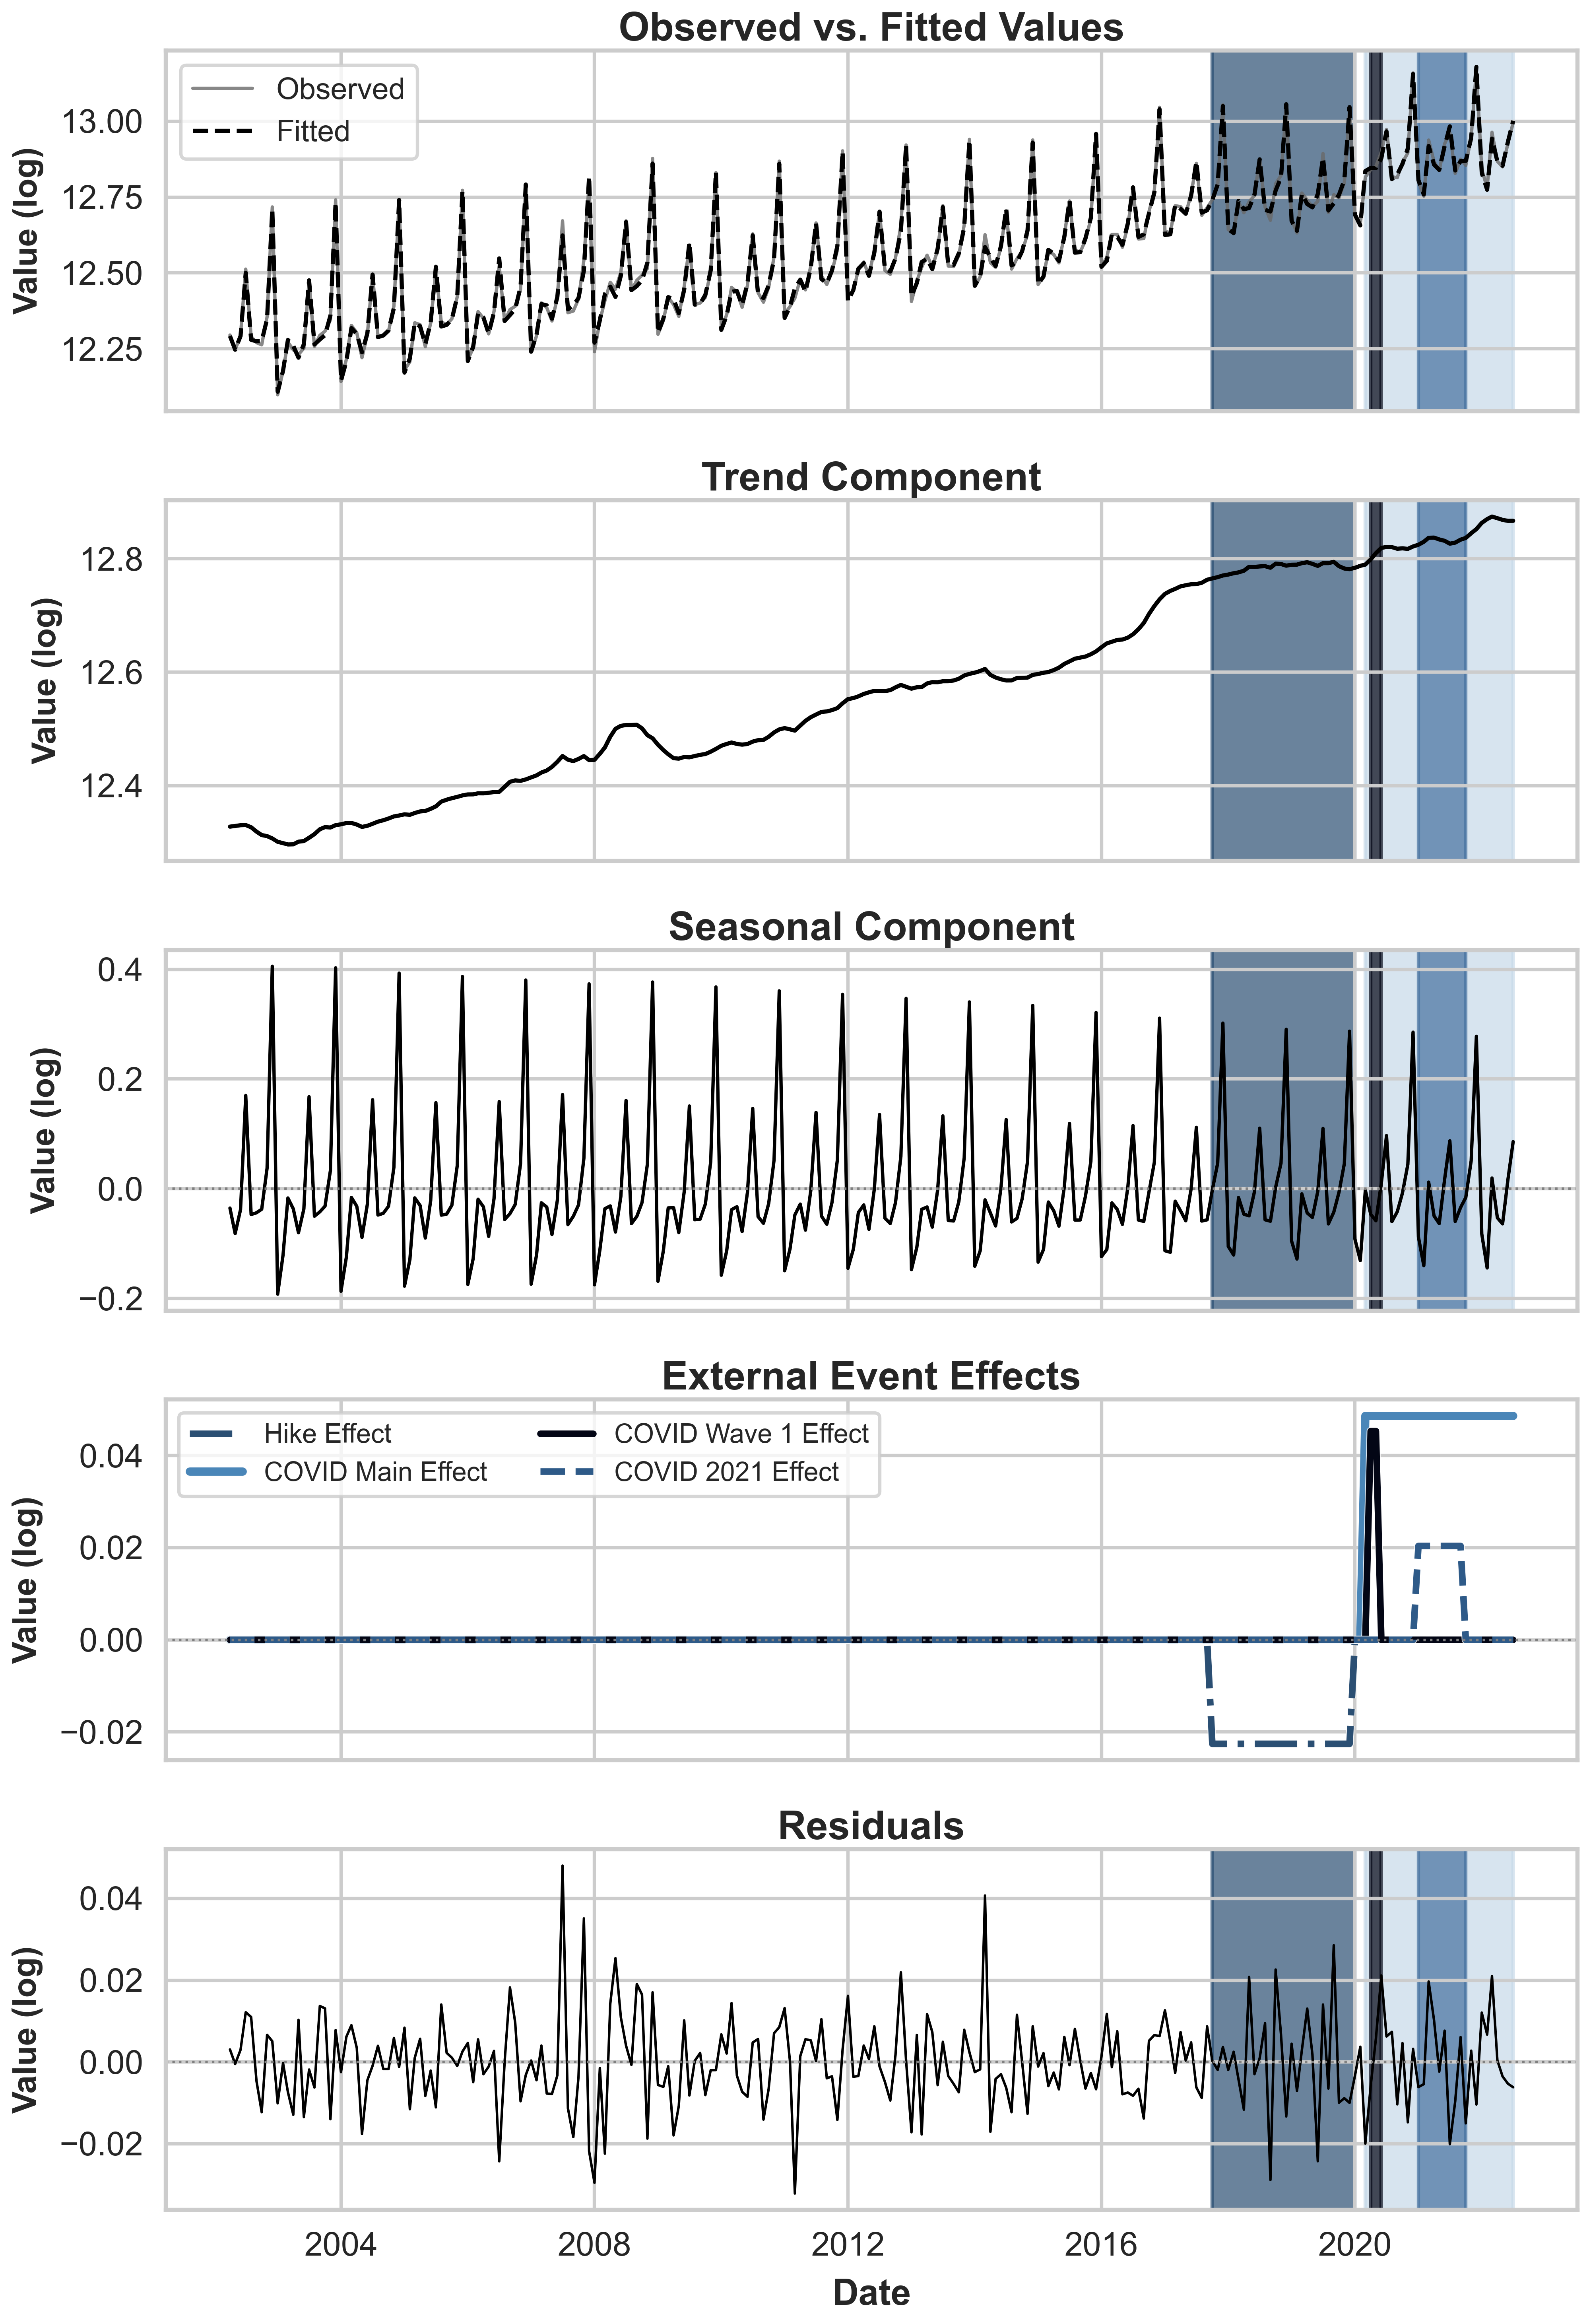

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe

# --- 1. Color Definitions ---
event_colors = {
    'hike_dummy': '#2B4F73',   # Dark Blue
    'covid_main': '#4A86B8',   # Medium Blue
    'covid_wave1': '#030615',  # Black/Navy
    'covid_2021': '#2E5A88',   # Dark Blue
}
bg_colors = {
    'hike_dummy': '#2B4F73',
    'covid_main': '#C6D9E9',   # Lighter blue for background
    'covid_wave1': '#030615',
    'covid_2021': '#4671A0',
}

# --- 2. Global Style Settings ---
sns.set_theme(style="whitegrid", context="poster")
plt.rcParams['font.family'] = 'sans-serif'

# Figure setup
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 20), sharex=True, dpi=300)

# --- 3. Plotting Components ---

# (1) Observed vs Fitted
axes[0].plot(df['label'], df['y'], color='dimgray', label='Observed', linewidth=2, alpha=0.8)
axes[0].plot(df['label'], fitted_values, color='black', linestyle='--', label='Fitted', linewidth=2.5)
axes[0].set_title('Observed vs. Fitted Values', fontsize=24, fontweight='bold')
axes[0].legend(loc='upper left', frameon=True, fontsize=18)

# (2) Trend
axes[1].plot(df['label'], trend_smoothed, color='black', label='Trend', linewidth=2.5)
axes[1].set_title('Trend Component', fontsize=24, fontweight='bold')

# (3) Seasonal
axes[2].plot(df['label'], seasonal_smoothed, color='black', label='Seasonal', linewidth=2)
axes[2].set_title('Seasonal Component', fontsize=24, fontweight='bold')
axes[2].axhline(y=0, color='grey', linestyle=':', linewidth=1.5)

# (4) External Event Effects
# ★ここがポイント：背景をなくす代わりに、線を太く強調して見やすくする
# 白の縁取り効果 (線が背景のグリッドに埋もれないようにする)
outline_effect = [pe.Stroke(linewidth=5, foreground='white', alpha=0.8), pe.Normal()]

axes[3].plot(df['label'], hike_effect_full, 
             color=event_colors['hike_dummy'], linestyle='-.', linewidth=4, 
             label='Hike Effect', path_effects=outline_effect)

axes[3].plot(df['label'], covid_main_effect_full, 
             color=event_colors['covid_main'], linestyle='-', linewidth=5, 
             label='COVID Main Effect', alpha=1.0, path_effects=outline_effect)

axes[3].plot(df['label'], covid_wave1_effect_full, 
             color=event_colors['covid_wave1'], linestyle='-', linewidth=4, 
             label='COVID Wave 1 Effect', path_effects=outline_effect)

axes[3].plot(df['label'], covid_2021_effect_full, 
             color=event_colors['covid_2021'], linestyle='--', linewidth=4, 
             label='COVID 2021 Effect', path_effects=outline_effect)

axes[3].set_title('External Event Effects', fontsize=24, fontweight='bold')
axes[3].axhline(y=0, color='grey', linestyle=':', linewidth=1.5)
axes[3].legend(loc='upper left', frameon=True, fontsize=16, ncol=2)

# (5) Residuals
axes[4].plot(df['label'], residuals_phase, color='black', linewidth=1.5, label='Residuals')
axes[4].set_title('Residuals', fontsize=24, fontweight='bold')
axes[4].axhline(y=0, color='grey', linestyle=':', linewidth=1.5)

# --- 4. Common Settings ---
# ループを使って背景色を設定しますが、
# ★「4段目のグラフ(axes[3])」だけはif文で除外して背景色を塗らないようにします
for i, ax in enumerate(axes):
    
    # 軸ラベルの設定（全グラフ共通）
    ax.set_ylabel('Value (log)', fontsize=20, fontweight='bold', labelpad=10)
    ax.tick_params(axis='both', which='major', labelsize=20, length=10, width=2.5, direction='out')

    # ★4段目 (External Event Effects) は背景帯を描画しない
    # （線そのものが見えにくくなるのを防ぐため）
    if i == 3:
        continue

    # 他のグラフには背景帯を描画
    # alpha=0.3 (濃すぎず薄すぎず、データが見える範囲で強調)
    ax.axvspan("2017-10-01", "2019-12-31", color=bg_colors['hike_dummy'], 
               alpha=0.7, zorder=-1)
    
    ax.axvspan("2020-03-01", df['label'].max(), color=bg_colors['covid_main'], 
               alpha=0.7, zorder=-2)
    
    ax.axvspan("2020-04-01", "2020-05-31", color=bg_colors['covid_wave1'], 
               alpha=0.7, zorder=-1)
    
    ax.axvspan("2021-01-01", "2021-09-30", color=bg_colors['covid_2021'], 
               alpha=0.7, zorder=-1)

# X-axis Label
axes[4].set_xlabel('Date', fontsize=22, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

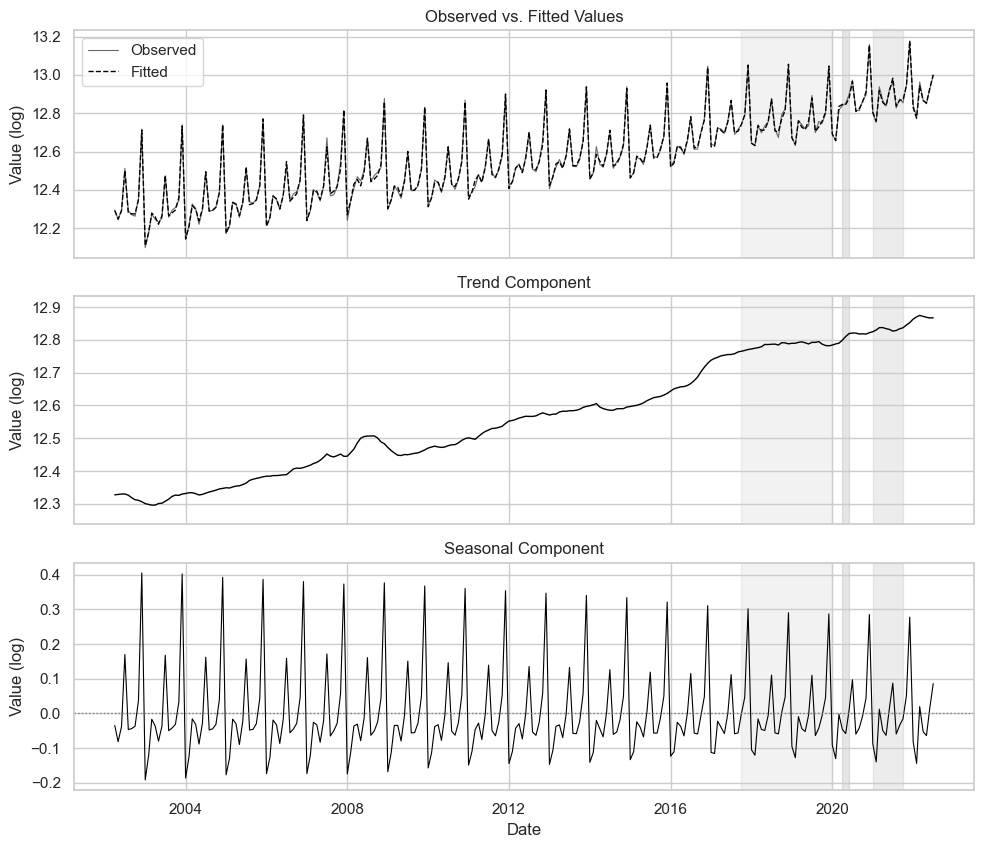

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 図1の準備 (3行1列) ---
fig1, axes1 = plt.subplots(nrows=3, ncols=1, figsize=(10, 9), sharex=True)
sns.set_theme(style="whitegrid")
#fig1.suptitle('Main Time Series Components', fontsize=16)

# --- 1. 観測値とモデルのフィット ---
axes1[0].plot(df['label'], df['y'], color='dimgray', label='Observed', linewidth=0.8)
axes1[0].plot(df['label'], fitted_values, color='black', linestyle='--', label='Fitted', linewidth=1)
axes1[0].set_title('Observed vs. Fitted Values')
axes1[0].legend(loc='upper left')

# --- 2. トレンド成分 ---
axes1[1].plot(df['label'], trend_smoothed, color='black', label='Trend', lw=1)
axes1[1].set_title('Trend Component')
# Y軸の範囲を自動調整
trend_min = trend_smoothed.min()
trend_max = trend_smoothed.max()
margin = (trend_max - trend_min) * 0.1
axes1[1].set_ylim(trend_min - margin, trend_max + margin)

# --- 3. 季節成分 ---
axes1[2].plot(df['label'], seasonal_smoothed, color='black', label='Seasonal', lw=0.8)
axes1[2].set_title('Seasonal Component')
axes1[2].axhline(y=0, color='grey', linestyle=':', linewidth=1)

# --- 図1共通の設定 ---
for ax in axes1:
    ax.axvspan("2017-10-01", "2019-12-31", color='gray', alpha=0.1, zorder=-1)
    ax.axvspan("2020-04-01", "2020-05-31", color='gray', alpha=0.2, zorder=-1)
    ax.axvspan("2021-01-01", "2021-09-30", color='gray', alpha=0.15, zorder=-1)
    ax.set_ylabel('Value (log)')

axes1[2].set_xlabel('Date', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # suptitleとの重なりを調整
plt.show()
# fig1.savefig('output/decomposition_part1.png', dpi=300)

In [ ]:
df_ssm = pd.DataFrame({
    'trend': trend_smoothed,
    'seasonal': seasonal_smoothed,
    'hike_effect': hike_effect_full.values,
    'covid_main_effect': covid_main_effect_full.values,
    'covid_wave1_effect': covid_wave1_effect_full.values,
    'covid_2021_effect': covid_2021_effect_full.values,
    'fitted': fitted_values.values,
    'residual': residuals_phase.values
}, index=df['label'])

df_ssm

,trend,seasonal,hike_effect,covid_main_effect,covid_wave1_effect,covid_2021_effect,fitted,residual
label,,,,,,,,
2002-04-01,12.327668,-0.035178,-0.0,0.000000,0.0,0.0,12.292490,0.003063
2002-05-01,12.328829,-0.081681,-0.0,0.000000,0.0,0.0,12.247147,-0.000494
2002-06-01,12.330160,-0.037976,-0.0,0.000000,0.0,0.0,12.292184,0.002966
2002-07-01,12.330468,0.170054,-0.0,0.000000,0.0,0.0,12.500523,0.012166
2002-08-01,12.326577,-0.046942,-0.0,0.000000,0.0,0.0,12.279636,0.011008
...,...,...,...,...,...,...,...,...
2022-03-01,12.874458,0.019551,-0.0,0.048591,0.0,0.0,12.942600,0.021037
2022-04-01,12.871618,-0.052962,-0.0,0.048591,0.0,0.0,12.867247,0.000376
2022-05-01,12.868649,-0.063961,-0.0,0.048591,0.0,0.0,12.853279,-0.003533


In [ ]:
df_ssm.to_csv('../output/result_ssm.csv')

In [ ]:
# 型と欠損値の状況を一括確認
print(df_ssm.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 244 entries, 2002-04-01 to 2022-07-01
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   trend               244 non-null    float64
 1   seasonal            244 non-null    float64
 2   hike_effect         0 non-null      float64
 3   covid_main_effect   0 non-null      float64
 4   covid_wave1_effect  0 non-null      float64
 5   covid_2021_effect   0 non-null      float64
 6   fitted              0 non-null      float64
 7   residual            0 non-null      float64
dtypes: float64(8)
memory usage: 17.2 KB
None


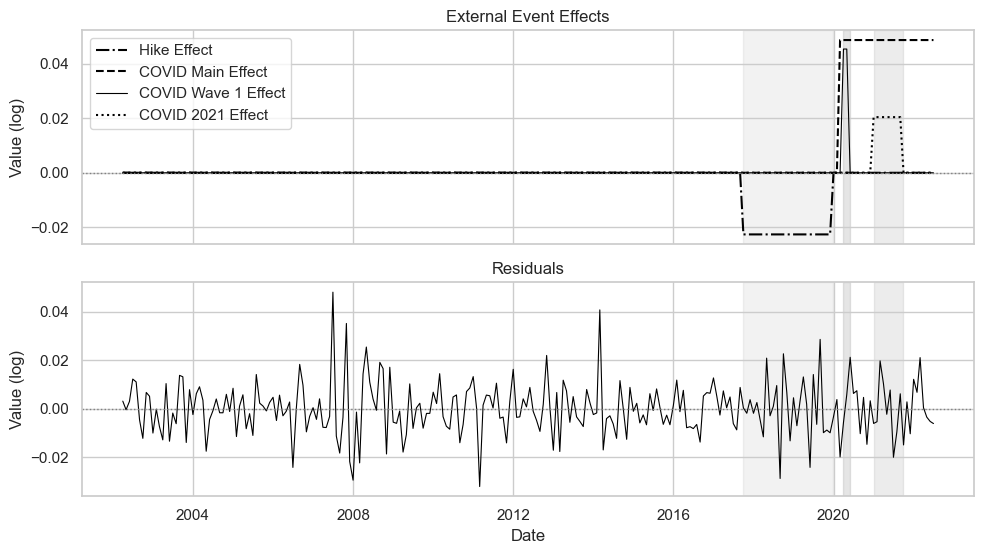

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 図2の準備 (2行1列) ---
fig2, axes2 = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
sns.set_theme(style="whitegrid")
#fig2.suptitle('External Event Effects and Residuals', fontsize=16)

# --- 1. 外部イベント効果 ---
axes2[0].plot(df['label'], hike_effect_full, color='black', linestyle='-.', label='Hike Effect')
axes2[0].plot(df['label'], covid_main_effect_full, color='black', linestyle='--', label='COVID Main Effect')
axes2[0].plot(df['label'], covid_wave1_effect_full, color='black', linestyle='-', label='COVID Wave 1 Effect', linewidth=0.8)
axes2[0].plot(df['label'], covid_2021_effect_full, color='black', linestyle=':', label='COVID 2021 Effect')
axes2[0].set_title('External Event Effects')
axes2[0].axhline(y=0, color='grey', linestyle=':', linewidth=1)
axes2[0].legend(loc='upper left')

# --- 2. 残差 ---
axes2[1].plot(df['label'], residuals_phase, color='black', linewidth=0.8, label='Residuals')
axes2[1].set_title('Residuals')
axes2[1].axhline(y=0, color='grey', linestyle=':', linewidth=1)

# --- 図2共通の設定 ---
for ax in axes2:
    ax.axvspan("2017-10-01", "2019-12-31", color='gray', alpha=0.1, zorder=-1)
    ax.axvspan("2020-04-01", "2020-05-31", color='gray', alpha=0.2, zorder=-1)
    ax.axvspan("2021-01-01", "2021-09-30", color='gray', alpha=0.15, zorder=-1)
    ax.set_ylabel('Value (log)')

axes2[1].set_xlabel('Date', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # suptitleとの重なりを調整
plt.show()
#fig2.savefig('output/decomposition_part2.png', dpi=300)

### リーマンショック＋値上げ(固定)＋コロナ禍フェーズ分け(固定)モデル

In [ ]:
# (1) リーマンショックダミー
shock_dummy = ((df['label'] >= '2008-09-01') & (df['label'] <= '2009-04-30')).astype(int)

# (2) 値上げダミー
hike_dummy = ((df['label'] >= '2017-10-01') & (df['label'] <= '2019-12-31')).astype(int)

# (2) コロナ禍ダミー（フェーズ分け）
# 構造的な底上げ効果
covid_main = (df['label'] >= '2020-03-01').astype(int)

# 第1波の急増効果
covid_wave1 = ((df['label'] >= '2020-04-01') & (df['label'] <= '2020-05-31')).astype(int)

# 2021年の主要な宣言期
covid_2021 = ((df['label'] >= '2021-01-01') & (df['label'] <= '2021-09-30')).astype(int)
covid_2021 = ((df['label'] >= '2021-01-01') & (df['label'] <= '2021-09-30')).astype(int)

In [ ]:
import statsmodels.api as sm

class LocalLinearTrendSeasonalWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    """
    トレンド(レベル+傾き) + 季節性 + 複数の固定係数の外生変数
    """
    def __init__(self, endog, exog_list, param_names, **kwargs):
        k_states = 13
        k_posdef = 3
        
        self.param_names_custom = param_names
        self.num_exog = len(exog_list)
        
        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization='diffuse', **kwargs)

        self.ssm['design'] = np.zeros((1, k_states))
        self.ssm['design', 0, 0] = 1; self.ssm['design', 0, 2] = 1
        T = np.zeros((k_states, k_states)); T[0, 0], T[0, 1] = 1, 1; T[1, 1] = 1
        T[2, 2:] = -1
        for i in range(3, k_states): T[i, i - 1] = 1
        self.ssm['transition'] = T
        S = np.zeros((k_states, k_posdef)); S[0, 0] = 1; S[1, 1] = 1; S[2, 2] = 1
        self.ssm['selection'] = S

        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        self.ssm['obs_intercept'] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        c = unconstrained.copy(); c[:4] = c[:4] ** 2 
        return c

    def untransform_params(self, constrained):
        u = constrained.copy(); u[:4] = np.sqrt(u[:4])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self['obs_cov', 0, 0] = params[0]
        self['state_cov', 0, 0] = params[1]
        self['state_cov', 1, 1] = params[2]
        self['state_cov', 2, 2] = params[3]
        
        total_exog_effect = 0
        for i in range(self.num_exog):
            total_exog_effect += params[4 + i] * self.exogs[i]
        self['obs_intercept', 0, :] = total_exog_effect

In [ ]:
# モデルに渡す外生変数のリスト
exog_vars = [shock_dummy, hike_dummy, covid_main, covid_wave1, covid_2021]

# モデルのパラメータ名
model_param_names = [
    'obs_error', 'level_noise', 'slope_noise', 'seasonal_noise',
    'shock_effect', 'hike_effect', 'covid_main_effect', 'covid_wave1_effect', 'covid_2021_effect'
]

# モデルのインスタンス化 (この部分は変更なし)
model_final = LocalLinearTrendSeasonalWithMultiFixedExog(
    endog=df['y'],
    exog_list=exog_vars,
    param_names=model_param_names
)

# 初期パラメータのリストを更新 
start_params_for_model = [0.01, 0.01, 0.001, 0.001, -1.0, 0.0, -2.0, -2.0, -3.0]

# モデルのフィット (この部分は変更なし)
result_final = model_final.fit(start_params=start_params_for_model, maxiter=1000)

# 結果の表示
print("--- 最終モデル（リーマン＋値上げ＋コロナ禍フェーズ分け）の結果 ---")
print(result_final.summary())

print(f"\n最終モデルのAIC: {result_final.aic:.3f}")

--- 最終モデル（リーマン＋値上げ＋コロナ禍フェーズ分け）の結果 ---
                                       Statespace Model Results                                       
Dep. Variable:                                              y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalWithMultiFixedExog   Log Likelihood                 480.949
Date:                                        Sat, 20 Sep 2025   AIC                           -917.899
Time:                                                17:14:10   BIC                           -840.961
Sample:                                                     0   HQIC                          -886.912
                                                        - 244                                         
Covariance Type:                                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [ ]:
# 最終モデルのスムージング結果を取得
smoothed_final = result_final.smoother_results

# 各成分を抽出
trend_smoothed_final = smoothed_final.smoothed_state[0]
seasonal_smoothed_final = smoothed_final.smoothed_state[2]

# 外生変数の効果を計算
shock_effect_full_final = result_final.params['shock_effect'] * shock_dummy
hike_effect_full_final = result_final.params['hike_effect'] * hike_dummy
covid_main_effect_full_final = result_final.params['covid_main_effect'] * covid_main
covid_wave1_effect_full_final = result_final.params['covid_wave1_effect'] * covid_wave1
covid_2021_effect_full_final = result_final.params['covid_2021_effect'] * covid_2021

# フィット値と残差を再計算
fitted_values_final = (trend_smoothed_final + seasonal_smoothed_final + 
                       shock_effect_full_final + hike_effect_full_final + 
                       covid_main_effect_full_final + covid_wave1_effect_full_final + 
                       covid_2021_effect_full_final)
residuals_final = df['y'].values - fitted_values_final

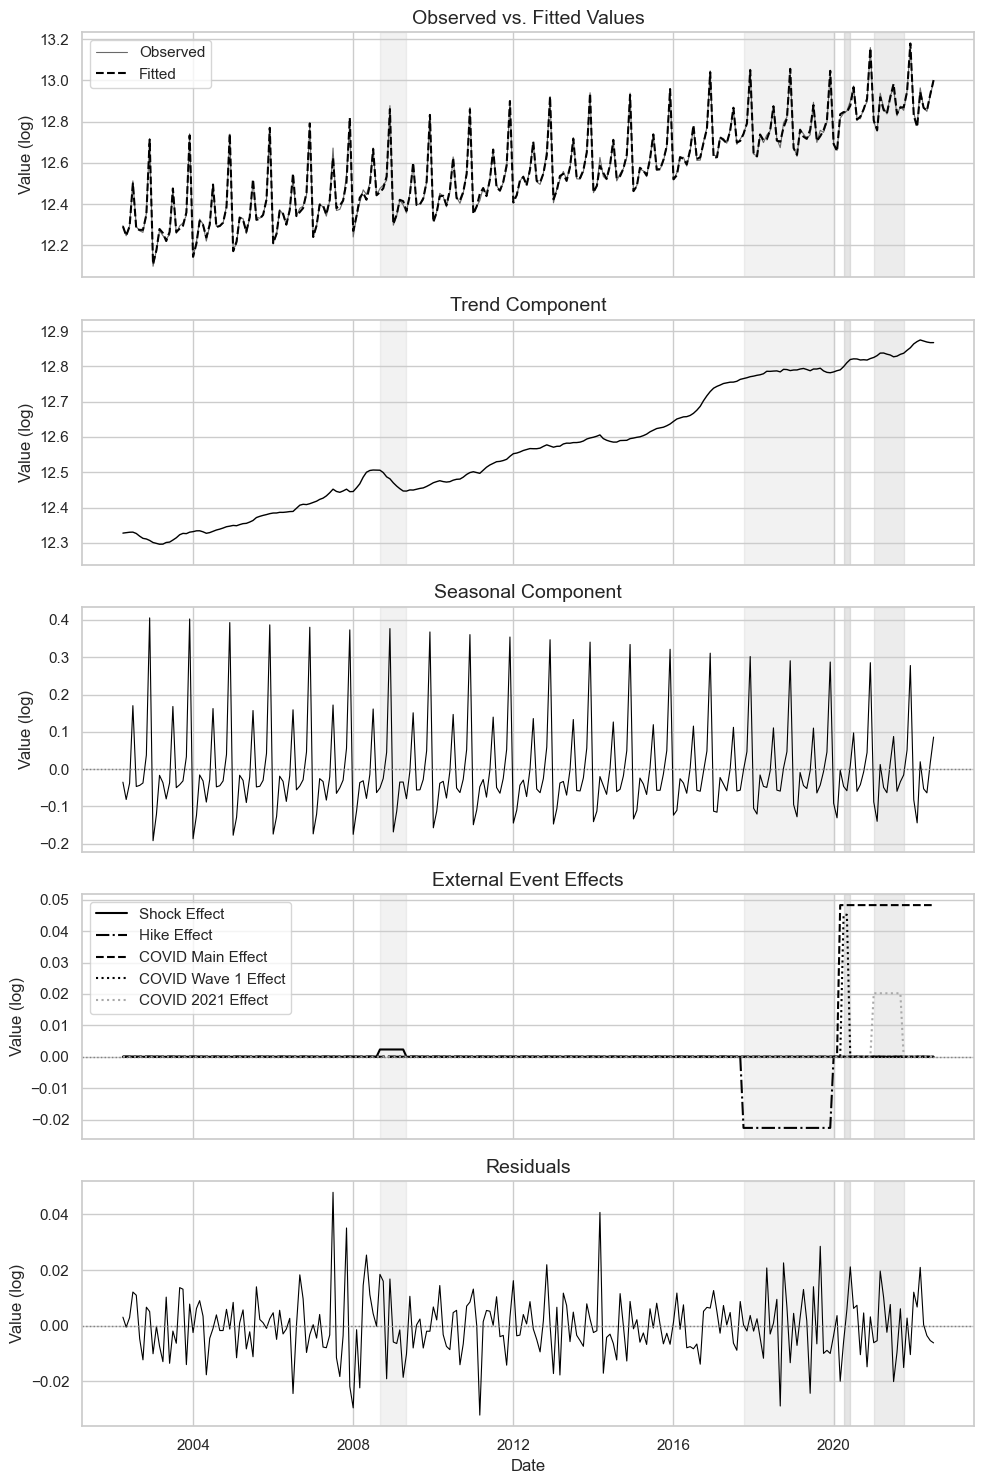

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- グラフの準備 ---
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)
sns.set_theme(style="whitegrid")

# --- 1. 観測値とモデルのフィット ---
axes[0].plot(df['label'], df['y'], color='dimgray', label='Observed', linewidth=0.8)
axes[0].plot(df['label'], fitted_values_final, color='black', linestyle='--', label='Fitted') # ← 変更点
axes[0].set_title('Observed vs. Fitted Values', fontsize=14)
axes[0].legend(loc='upper left')

# --- 2. トレンド成分 ---
axes[1].plot(df['label'], trend_smoothed_final, color='black', label='Trend', lw=1) # ← 変更点
axes[1].set_title('Trend Component', fontsize=14)
# Y軸の範囲を自動調整
trend_min = trend_smoothed_final.min()
trend_max = trend_smoothed_final.max()
margin = (trend_max - trend_min) * 0.1
axes[1].set_ylim(trend_min - margin, trend_max + margin)

# --- 3. 季節成分 ---
axes[2].plot(df['label'], seasonal_smoothed_final, color='black', label='Seasonal', lw=0.8) # ← 変更点
axes[2].set_title('Seasonal Component', fontsize=14)
axes[2].axhline(y=0, color='grey', linestyle=':', linewidth=1)

# --- 4. 外部イベント効果 ---
# 複数のイベント効果を線種を変えてプロット
axes[3].plot(df['label'], shock_effect_full_final, color='black', linestyle='-', label='Shock Effect', linewidth=1.5) # ← 追加点
axes[3].plot(df['label'], hike_effect_full_final, color='black', linestyle='-.', label='Hike Effect') # ← 変更点
axes[3].plot(df['label'], covid_main_effect_full_final, color='black', linestyle='--', label='COVID Main Effect') # ← 変更点
axes[3].plot(df['label'], covid_wave1_effect_full_final, color='black', linestyle=':', label='COVID Wave 1 Effect') # ← 変更点
axes[3].plot(df['label'], covid_2021_effect_full_final, color='darkgrey', linestyle=':', label='COVID 2021 Effect') # ← 変更点
axes[3].set_title('External Event Effects', fontsize=14)
axes[3].axhline(y=0, color='grey', linestyle=':', linewidth=1)
axes[3].legend(loc='upper left')

# --- 5. 残差 ---
axes[4].plot(df['label'], residuals_final, color='black', linewidth=0.8, label='Residuals') # ← 変更点
axes[4].set_title('Residuals', fontsize=14)
axes[4].axhline(y=0, color='grey', linestyle=':', linewidth=1)

# --- 全グラフ共通の設定 ---
for ax in axes:
    ax.axvspan("2008-09-01", "2009-04-30", color='gray', alpha=0.1, zorder=-1) 
    ax.axvspan("2017-10-01", "2019-12-31", color='gray', alpha=0.1, zorder=-1)
    ax.axvspan("2020-04-01", "2020-05-31", color='gray', alpha=0.2, zorder=-1)
    ax.axvspan("2021-01-01", "2021-09-30", color='gray', alpha=0.15, zorder=-1)
    ax.set_ylabel('Value (log)')

# 最後のグラフにのみX軸のラベルを表示
axes[4].set_xlabel('Date', fontsize=12)

# レイアウトの自動調整
plt.tight_layout()

# グラフの表示と保存
plt.show()
#fig.savefig('output/decomposition_bw_final.png', dpi=300)

### ハイパラ探索

In [ ]:
import optuna
import numpy as np

# --- ダミー変数の準備（変更なし） ---
hike_dummy = ((df['label'] >= '2017-10-01') & (df['label'] <= '2019-12-31')).astype(int)
covid_main = (df['label'] >= '2020-03-01').astype(int)

# --- ★ここからが今回の実験用の設定 ---

# 目的関数を2変数用に修正
def objective_2exog(trial):
    # 2つの外生変数係数の初期値を探索
    start_hike = trial.suggest_float('start_hike', -0.2, 0.2)
    start_covid_main = trial.suggest_float('start_covid_main', -0.2, 0.2)
    
    # start_paramsのリストを2変数用に構築 (合計6パラメータ)
    start_params_for_trial = [
        0.01, 0.01, 0.001, 0.001,
        start_hike, start_covid_main
    ]
    
    # モデルのインスタンス化も2変数用に変更
    model = LocalLinearTrendSeasonalWithMultiFixedExog(
        endog=df['y'], 
        exog_list=[hike_dummy, covid_main], # 渡すダミーも2つだけ
        param_names=[ # パラメータ名も2つだけ
            'obs_error', 'level_noise', 'slope_noise', 'seasonal_noise',
            'hike_effect', 'covid_main_effect'
        ]
    )
    
    try:
        result = model.fit(start_params=start_params_for_trial, maxiter=1000, disp=0)
        return result.loglike
    except Exception:
        return -np.inf

# 探索の実行
study_2exog = optuna.create_study(direction='maximize')
study_2exog.optimize(objective_2exog, n_trials=50)

# 結果の表示
print("\n--- Optunaによる初期値探索の結果（2変数版） ---")
print(f"Number of finished trials: {len(study_2exog.trials)}")
print(f"Best trial's value (Log Likelihood): {study_2exog.best_value}")
print("Best trial's start_params for exog:")
print(study_2exog.best_params)

[I 2025-07-03 13:53:58,794] A new study created in memory with name: no-name-03f1ac16-41e0-4a3f-8cdd-a034a5ea7d20
[I 2025-07-03 13:53:59,031] Trial 0 finished with value: -inf and parameters: {'start_hike': 0.1579922472513423, 'start_covid_main': -0.1409689842059424}. Best is trial 0 with value: -inf.
[I 2025-07-03 13:53:59,429] Trial 1 finished with value: -inf and parameters: {'start_hike': -0.17044285103755186, 'start_covid_main': 0.09079192484364046}. Best is trial 0 with value: -inf.
[I 2025-07-03 13:53:59,652] Trial 2 finished with value: -inf and parameters: {'start_hike': 0.13683760931994554, 'start_covid_main': 0.09578849014880525}. Best is trial 0 with value: -inf.
[I 2025-07-03 13:53:59,841] Trial 3 finished with value: -inf and parameters: {'start_hike': 0.16968152899464112, 'start_covid_main': 0.016070170946743817}. Best is trial 0 with value: -inf.
[I 2025-07-03 13:54:00,059] Trial 4 finished with value: -inf and parameters: {'start_hike': 0.08074047624709313, 'start_covi


--- Optunaによる初期値探索の結果（2変数版） ---
Number of finished trials: 50
Best trial's value (Log Likelihood): -inf
Best trial's start_params for exog:
{'start_hike': 0.1579922472513423, 'start_covid_main': -0.1409689842059424}


# ハイパラ探索

In [ ]:
# 評価関数の定義
import optuna

def objective(trial):
    # 各パラメータの候補（非負, logスケールで探索）
    obs_error     = trial.suggest_float('obs_error',     1e-5, 1.0, log=True)
    level_noise   = trial.suggest_float('level_noise',   1e-5, 1.0, log=True)
    slope_noise   = trial.suggest_float('slope_noise',   1e-6, 1.0, log=True)
    seasonal_noise= trial.suggest_float('seasonal_noise',1e-6, 1.0, log=True)

    # モデルインスタンスの生成
    model = LocalLinearTrendSeasonalModel(endog)
    
    # パラメータをフィット
    try:
        res = model.fit(start_params=[obs_error, level_noise, slope_noise, seasonal_noise], disp=False)
        return -res.llf  # 負の対数尤度（小さいほど良い）
    except Exception as e:
        return float('inf')  # エラー時は大きな値を返す


In [ ]:
# 最適化の実行
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)

# 最適なパラメータ
print('Best params:', study.best_params)

[I 2025-06-30 13:51:44,054] A new study created in memory with name: no-name-b8d826e4-e75f-4f26-90bd-444de6374535
[I 2025-06-30 13:51:44,173] Trial 0 finished with value: -469.4512835538426 and parameters: {'obs_error': 0.0001768676933731629, 'level_noise': 0.2832616698597214, 'slope_noise': 7.893120007899728e-06, 'seasonal_noise': 0.0015103151781352595}. Best is trial 0 with value: -469.4512835538426.
[I 2025-06-30 13:51:44,325] Trial 1 finished with value: -469.4510870011759 and parameters: {'obs_error': 0.3773431954640535, 'level_noise': 3.6843029411434916e-05, 'slope_noise': 1.9532071038304343e-06, 'seasonal_noise': 4.3353498628986575e-06}. Best is trial 0 with value: -469.4512835538426.
[I 2025-06-30 13:51:44,489] Trial 2 finished with value: -469.45116470241584 and parameters: {'obs_error': 0.008764614012928227, 'level_noise': 0.00028238829276479733, 'slope_noise': 5.020195934818843e-05, 'seasonal_noise': 0.002810219945532139}. Best is trial 0 with value: -469.4512835538426.
c:\U

Best params: {'obs_error': 8.794512459692586e-05, 'level_noise': 0.07758395475774507, 'slope_noise': 8.483080742502029e-05, 'seasonal_noise': 0.04393715416274167}


In [ ]:
# 最適なパラメタで再度フィッティング

best_params = study.best_params
model_best = LocalLinearTrendSeasonalModel(endog)
res_best = model_best.fit(
    start_params=[best_params['obs_error'], 
                  best_params['level_noise'], 
                  best_params['slope_noise'], 
                  best_params['seasonal_noise']],
    disp=False
)
print(res_best.summary())


                                 Statespace Model Results                                
Dep. Variable:                                 y   No. Observations:                  244
Model:             LocalLinearTrendSeasonalModel   Log Likelihood                 469.451
Date:                           Mon, 30 Jun 2025   AIC                           -904.903
Time:                                   13:52:16   BIC                           -845.451
Sample:                                        0   HQIC                          -880.959
                                           - 244                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
obs_error          0.0002   4.95e-05      4.711      0.000       0.000       0.000
level_noise        0.0001   2.9